# Dataset Distribution Analysis

This notebook loads one or several trained GNN models, retrieves their `df_train`, `df_val` and `df_test` DataFrames, and compares feature distributions across the three splits.

**How to adapt to another config:** edit only the *Configuration* cell below.

## Configuration

> **Edit this cell to point to a different experiment.**

In [12]:
import sys

sys.path.insert(0, '/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction')
sys.path.insert(0, '/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN')

from tools import *

In [13]:
# ─── USER CONFIGURATION ──────────────────────────────────────────────────────

# Root directory that CONTAINS per-model sub-folders
NODE_ROOT = (
    "/home/caron/Bureau/ST-GNN-for-wildifre-prediction/"
    "Prediction/GNN/firemen/firepoint/2x2/train/"
    "occurence_06_01_25_78/check_z-score/"
    "full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node"
)

# Name of the output folder (created inside NODE_ROOT's parent)
OUTPUT_FOLDER_NAME = "full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3"

# List of model names to analyse.
# Each name must match BOTH the sub-folder and the .pkl file inside it.
MODEL_NAMES = [
    "GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}",
    # "GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{8}",
    # Add more model names here …
]

# Plotting options
N_COLS       = 3      # number of subplot columns per feature figure
BIN_COUNT    = 50     # histogram bins
FIGSIZE_W    = 18     # figure width (inches)
FIGSIZE_H    = 5      # height per row of subplots
DPI          = 120

# ─────────────────────────────────────────────────────────────────────────────

## Imports

In [14]:
import sys
import os
import pickle
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

warnings.filterwarnings("ignore")

# Make GNN importable
_prediction_path = Path(NODE_ROOT).parents[5]  # …/Prediction
for _p in [str(_prediction_path), str(_prediction_path.parent)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

print(f"NODE_ROOT      : {NODE_ROOT}")
print(f"Output folder  : {OUTPUT_FOLDER_NAME}")
print(f"Models to load : {MODEL_NAMES}")

NODE_ROOT      : /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node
Output folder  : full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3
Models to load : ['GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}']


## Helper functions

In [15]:
def load_model(model_name: str, node_root: str) -> object:
    """Load a pickled model from its standard location."""
    pkl_path = Path(node_root) / model_name / f"{model_name}.pkl"
    print(f"  Loading {pkl_path} …", end=" ", flush=True)
    with open(pkl_path, "rb") as fh:
        model = pickle.load(fh)
    print("OK")
    return model


def get_split_dfs(model) -> dict:
    """Return {split_name: DataFrame} for the three standard splits."""
    splits = {}
    for split in ("df_train", "df_val", "df_test"):
        df = getattr(model, split, None)
        if df is not None:
            splits[split.replace("df_", "")] = df.copy()
        else:
            print(f"  WARNING: attribute '{split}' not found on model.")
    return splits


def get_feature_columns(model, splits: dict) -> list:
    """Return the list of feature columns to plot."""
    # Prefer model.features_name if it exists
    features = getattr(model, "features_name", None)
    if features is not None:
        # Keep only columns that actually exist in at least one split
        all_cols = set()
        for df in splits.values():
            all_cols.update(df.columns.tolist())
        features = [f for f in features if f in all_cols]
        if features:
            return features
    # Fallback: numeric columns common to all splits
    common = None
    for df in splits.values():
        num_cols = set(df.select_dtypes(include=[np.number]).columns.tolist())
        common = num_cols if common is None else common & num_cols
    return sorted(common or [])


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


SPLIT_STYLES = {
    "train": {"color": "#4C72B0", "alpha": 0.65, "label": "Train"},
    "val":   {"color": "#DD8452", "alpha": 0.65, "label": "Val"},
    "test":  {"color": "#55A868", "alpha": 0.65, "label": "Test"},
}

## Plotting function

In [16]:
def plot_feature_distributions(
    splits: dict,
    features: list,
    model_name: str,
    out_dir: Path,
    n_cols: int = N_COLS,
    bins: int = BIN_COUNT,
    figsize_w: float = FIGSIZE_W,
    figsize_h: float = FIGSIZE_H,
    dpi: int = DPI,
    features_per_fig: int = 30,
) -> list:
    """
    Plot overlapping histograms (train / val / test) for every feature.

    Features are grouped in pages of `features_per_fig` to avoid
    figures with thousands of subplots.

    Returns the list of saved figure paths.
    """
    saved_paths = []
    safe_name   = model_name.replace("/", "_").replace(" ", "_")
    total       = len(features)
    n_pages     = math.ceil(total / features_per_fig)

    for page in range(n_pages):
        page_features = features[page * features_per_fig : (page + 1) * features_per_fig]
        n_rows = math.ceil(len(page_features) / n_cols)

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(figsize_w, figsize_h * n_rows),
            dpi=dpi,
        )
        axes_flat = np.array(axes).flatten() if n_rows * n_cols > 1 else [axes]

        for ax_idx, feat in enumerate(page_features):
            ax = axes_flat[ax_idx]
            any_data = False

            for split_name, style in SPLIT_STYLES.items():
                if split_name not in splits:
                    continue
                df = splits[split_name]
                if feat not in df.columns:
                    continue
                col = df[feat].dropna()
                if col.empty or not np.issubdtype(col.dtype, np.number):
                    continue
                ax.hist(
                    col,
                    bins=bins,
                    density=True,
                    alpha=style["alpha"],
                    color=style["color"],
                    label=f"{style['label']} (n={len(col):,})",
                )
                any_data = True

            ax.set_title(feat, fontsize=9, pad=4)
            ax.set_xlabel("value", fontsize=7)
            ax.set_ylabel("density", fontsize=7)
            ax.tick_params(labelsize=7)
            if any_data:
                ax.legend(fontsize=6)

        # Hide unused axes
        for ax in axes_flat[len(page_features):]:
            ax.set_visible(False)

        page_suffix = f"_page{page + 1}" if n_pages > 1 else ""
        fig.suptitle(
            f"Feature distributions — {model_name}{page_suffix}\n"
            f"(features {page * features_per_fig + 1}–{page * features_per_fig + len(page_features)} / {total})",
            fontsize=11,
            fontweight="bold",
        )
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        fig_path = out_dir / f"{safe_name}_distributions{page_suffix}.png"
        fig.savefig(fig_path, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        saved_paths.append(fig_path)
        print(f"  Saved → {fig_path}")

    return saved_paths


def summary_stats(splits: dict, features: list) -> pd.DataFrame:
    """Return a DataFrame with mean/std/min/max per feature and split."""
    rows = []
    for feat in features:
        for split_name, df in splits.items():
            if feat not in df.columns:
                continue
            col = df[feat].dropna()
            if col.empty or not np.issubdtype(col.dtype, np.number):
                continue
            rows.append({
                "feature": feat,
                "split":   split_name,
                "n":       len(col),
                "mean":    round(col.mean(), 4),
                "std":     round(col.std(),  4),
                "min":     round(col.min(),  4),
                "p25":     round(col.quantile(0.25), 4),
                "median":  round(col.median(), 4),
                "p75":     round(col.quantile(0.75), 4),
                "max":     round(col.max(),  4),
            })
    return pd.DataFrame(rows)

## Main loop – load models and generate plots

Plots will be saved to: /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3

Model: GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}
  Loading /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}.pkl … OK
  train:   30,681 rows × 502 cols
  val  :    8,085 rows × 502 cols
  test :    6,990 rows × 502 cols

  → 165 feature(s) to plot

  Generating distribution plots …


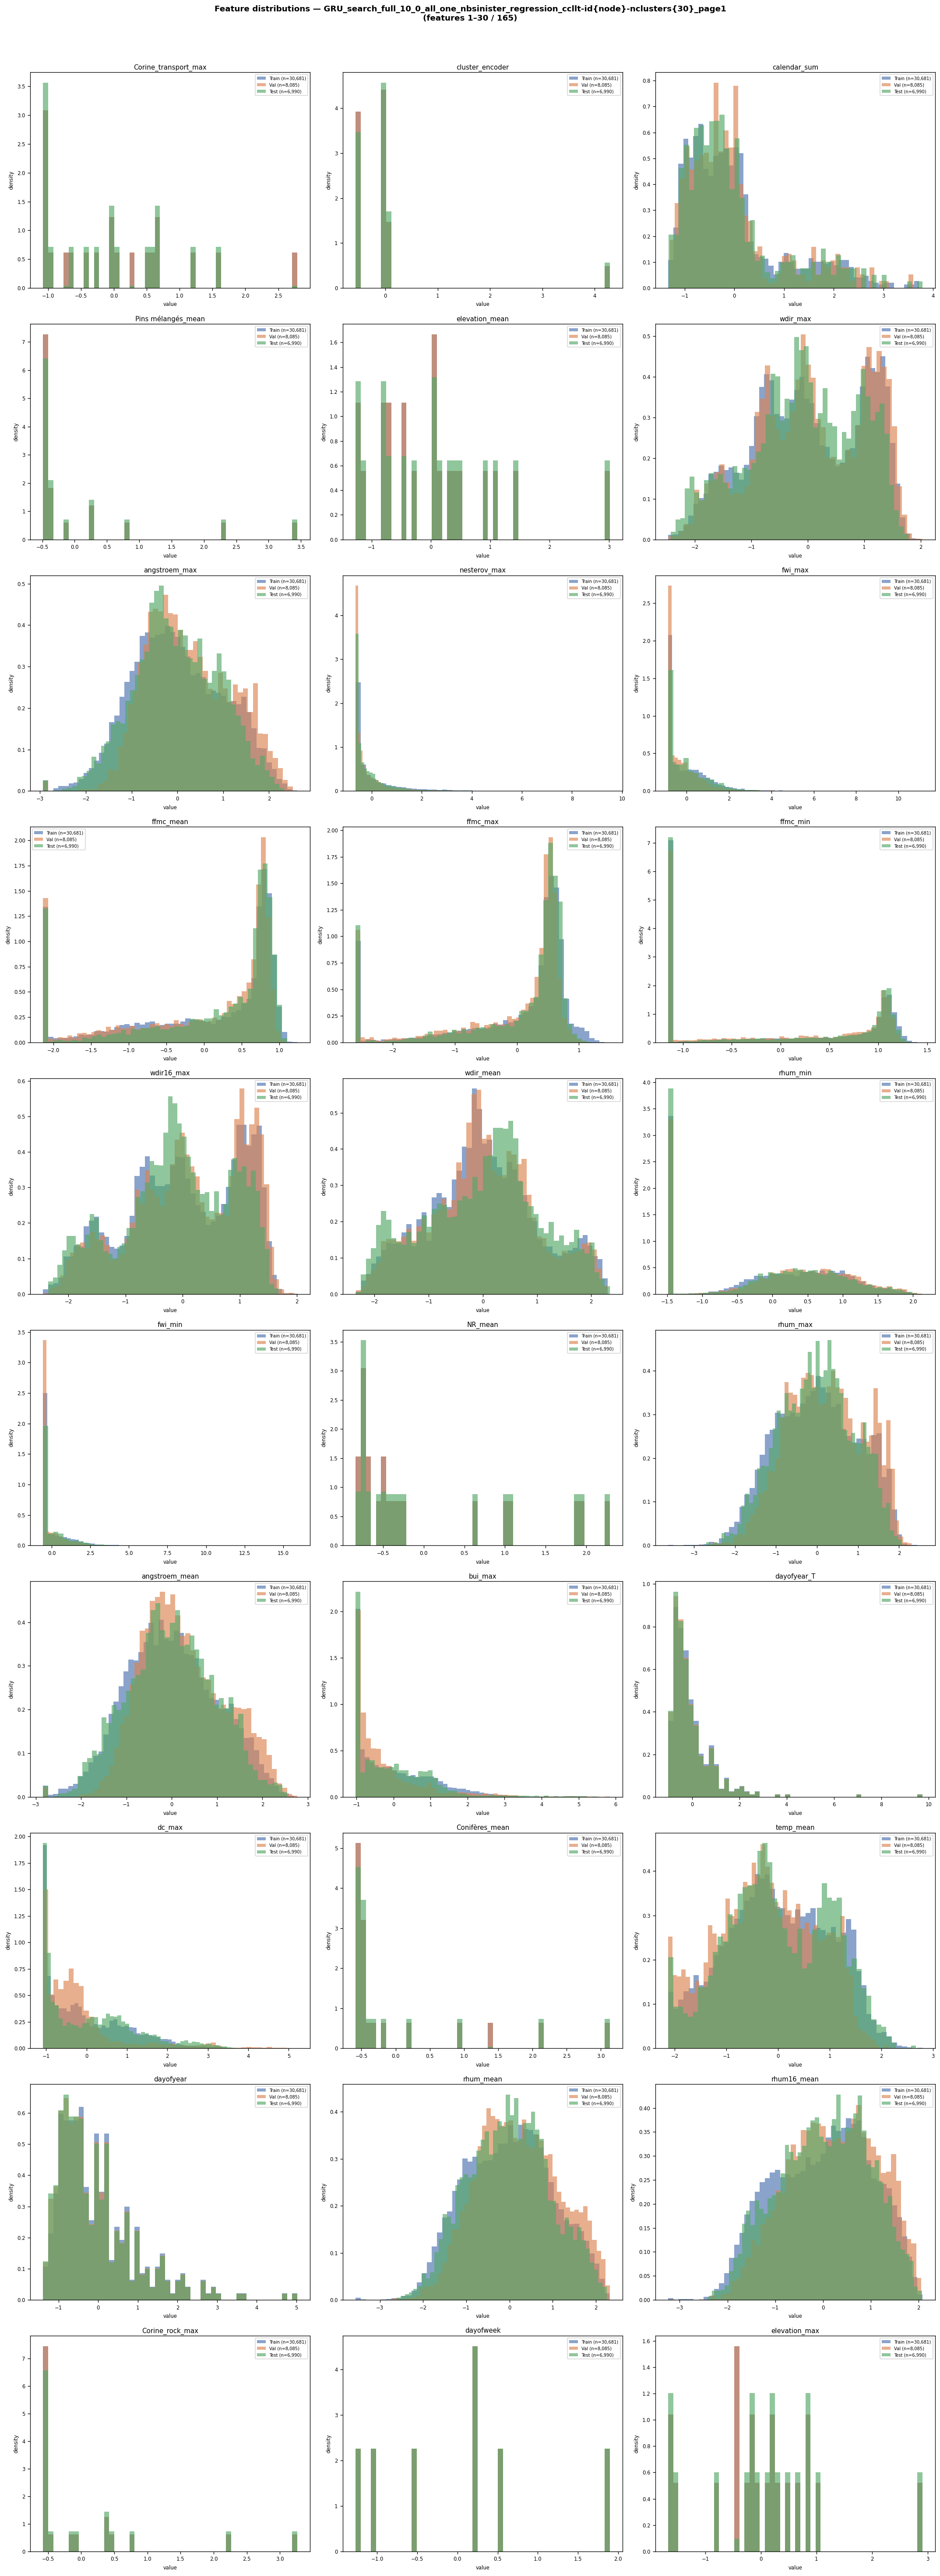

  Saved → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}_distributions_page1.png


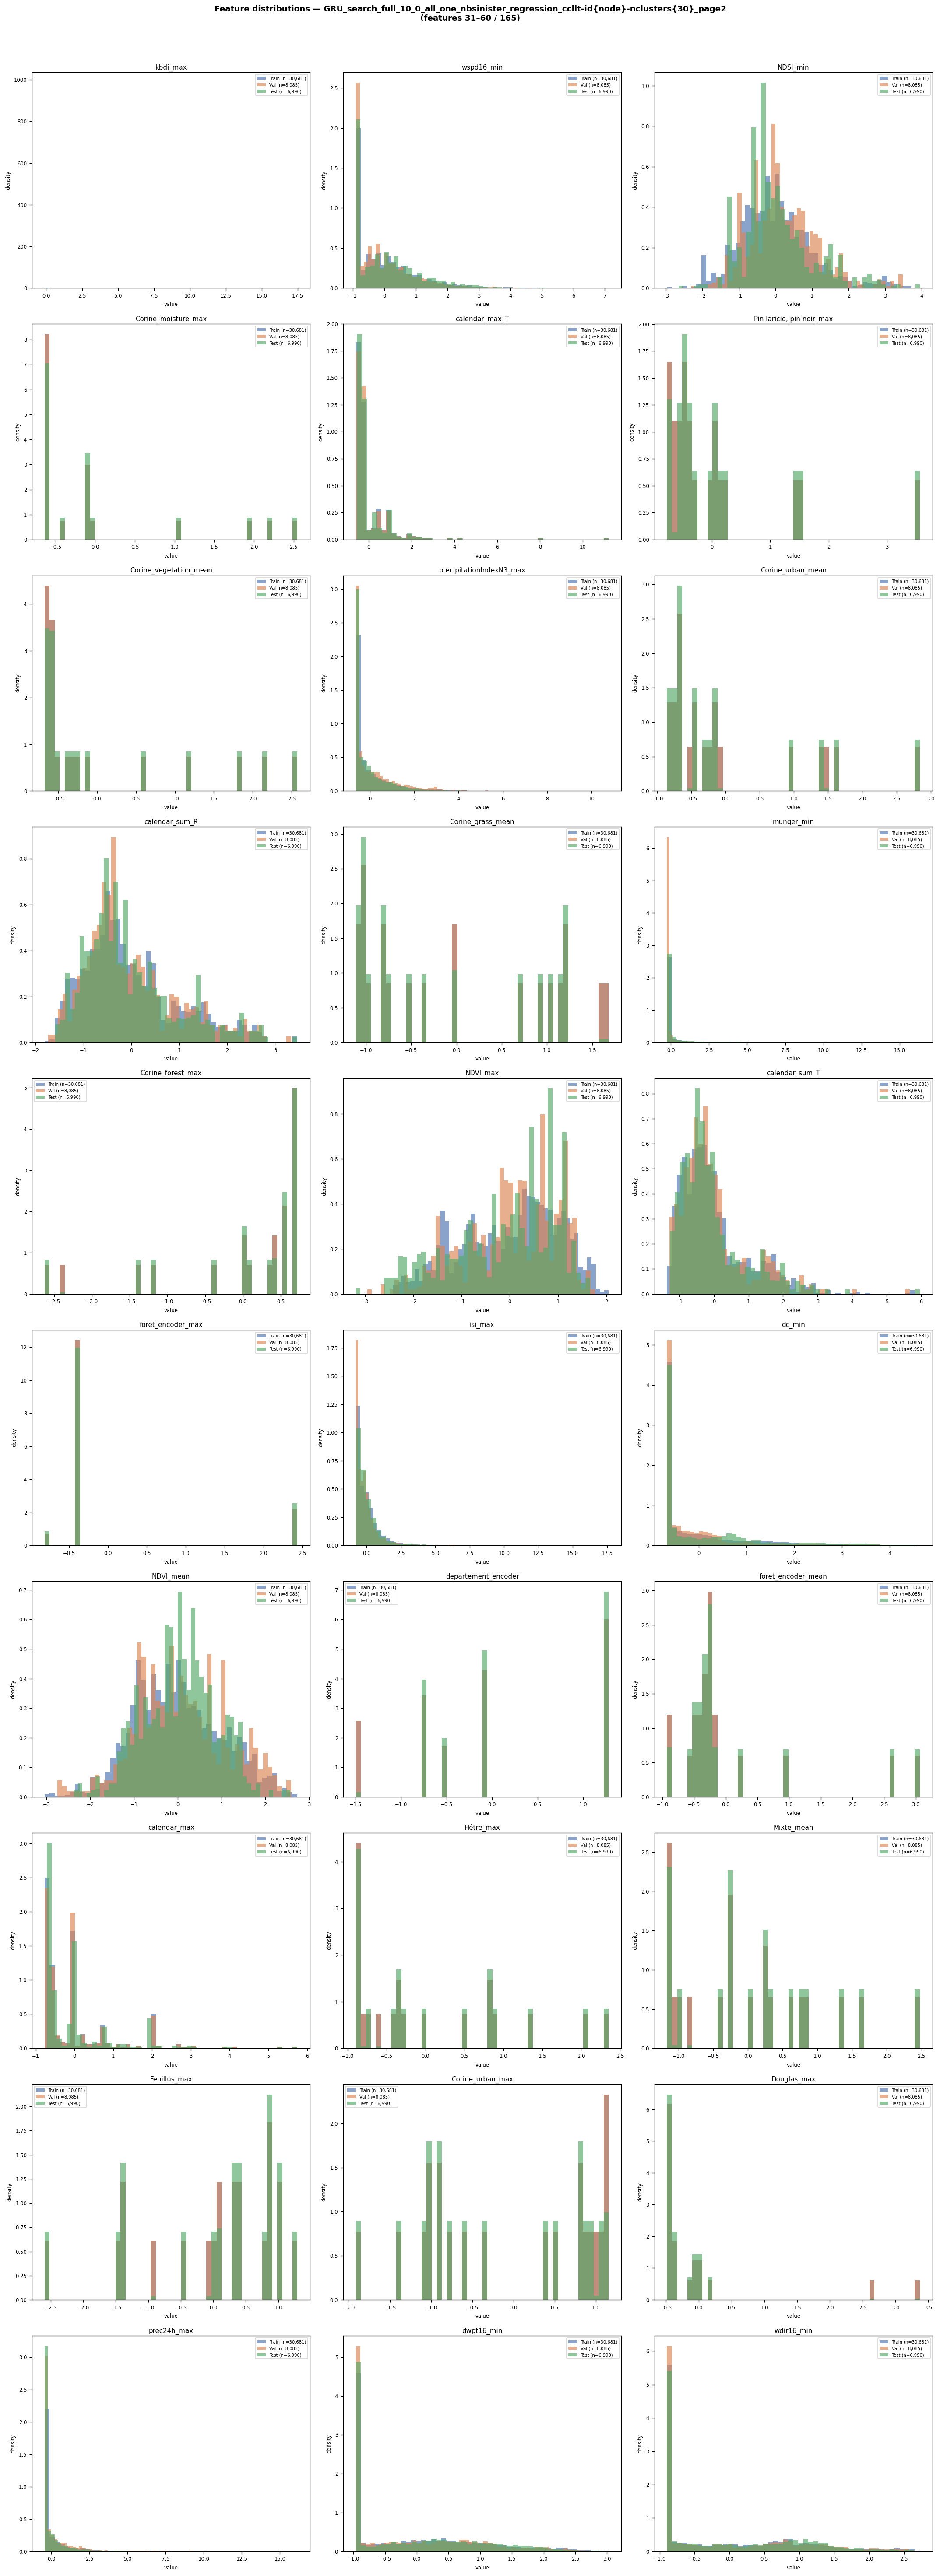

  Saved → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}_distributions_page2.png


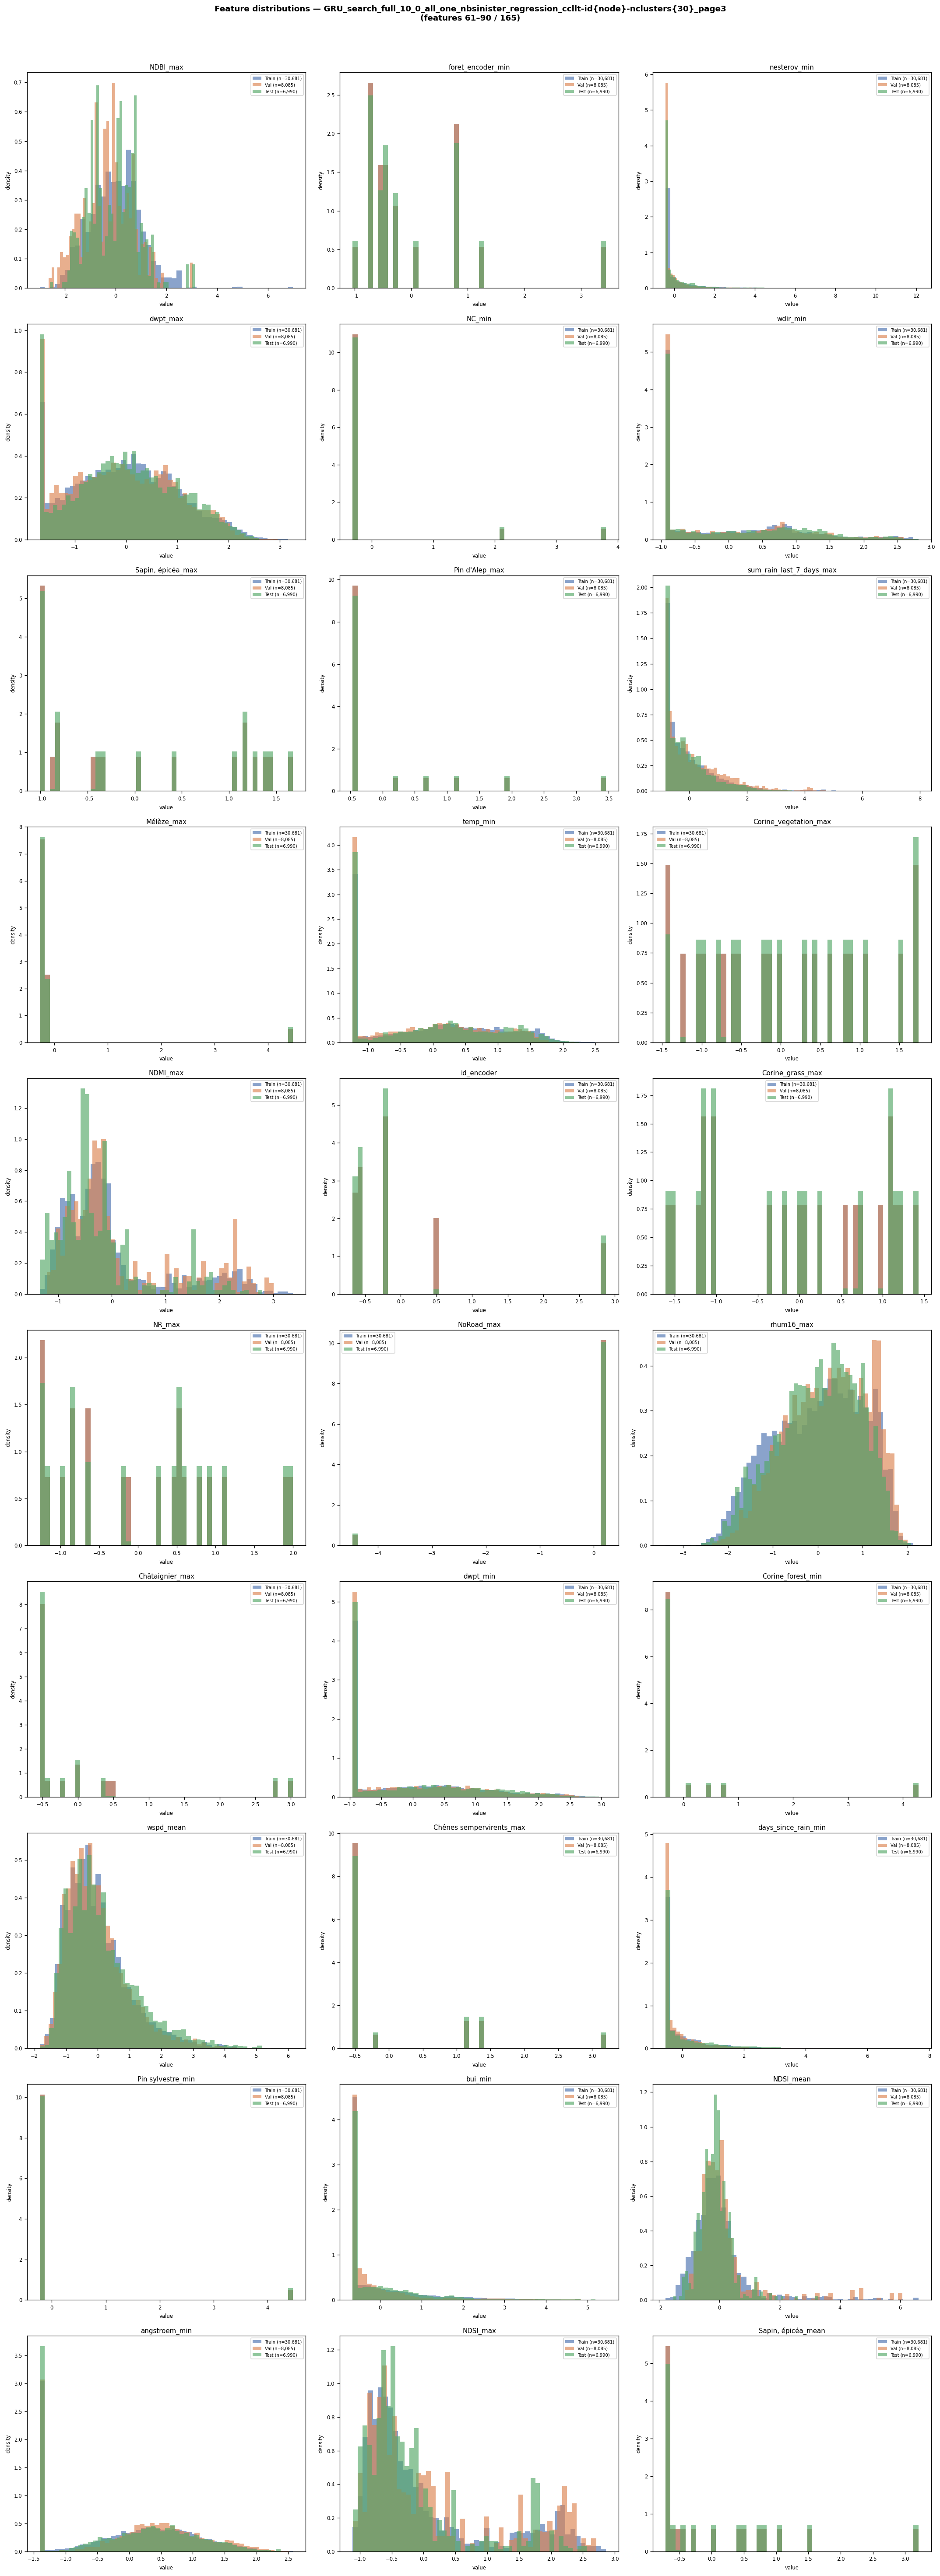

  Saved → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}_distributions_page3.png


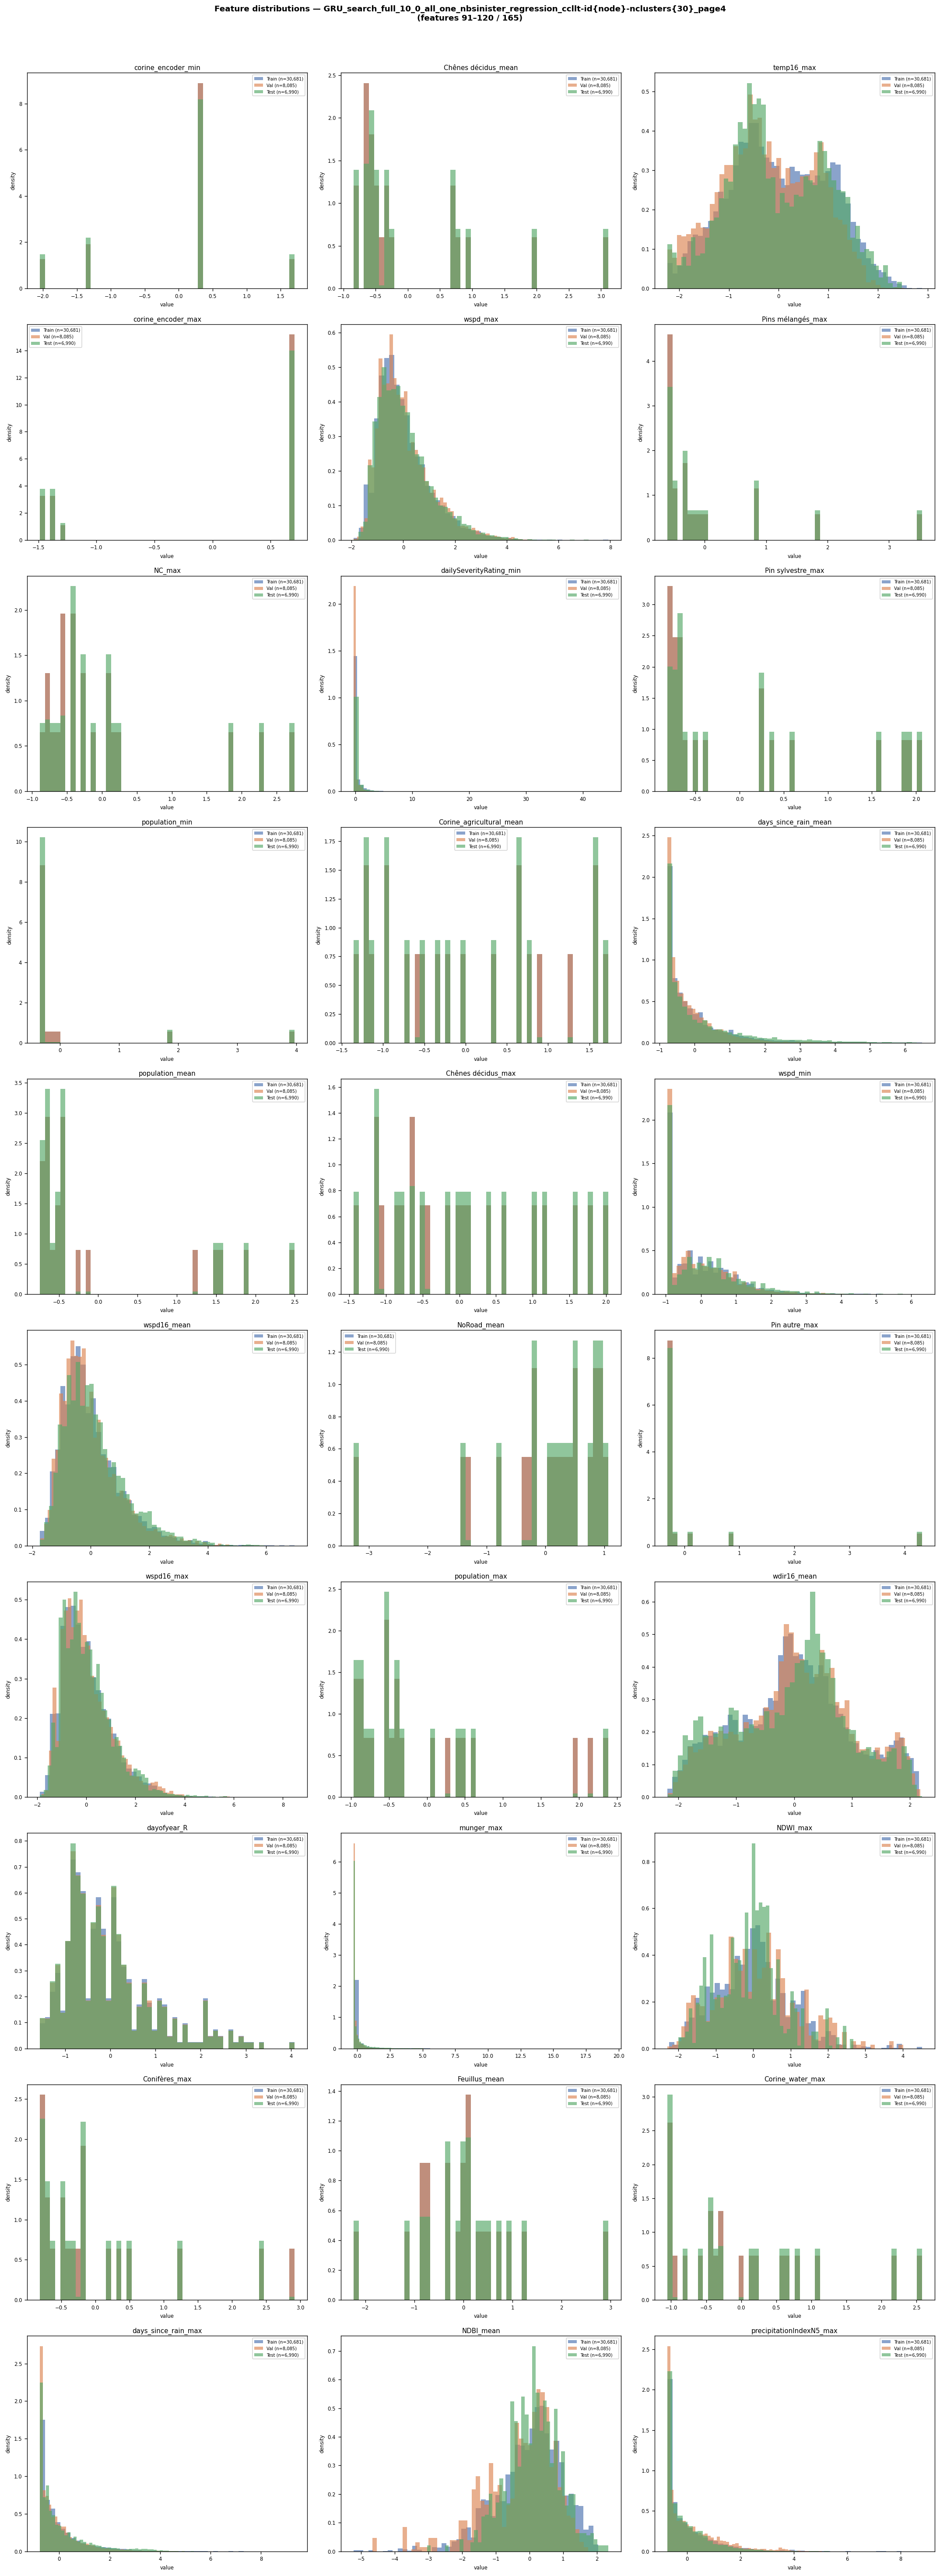

  Saved → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}_distributions_page4.png


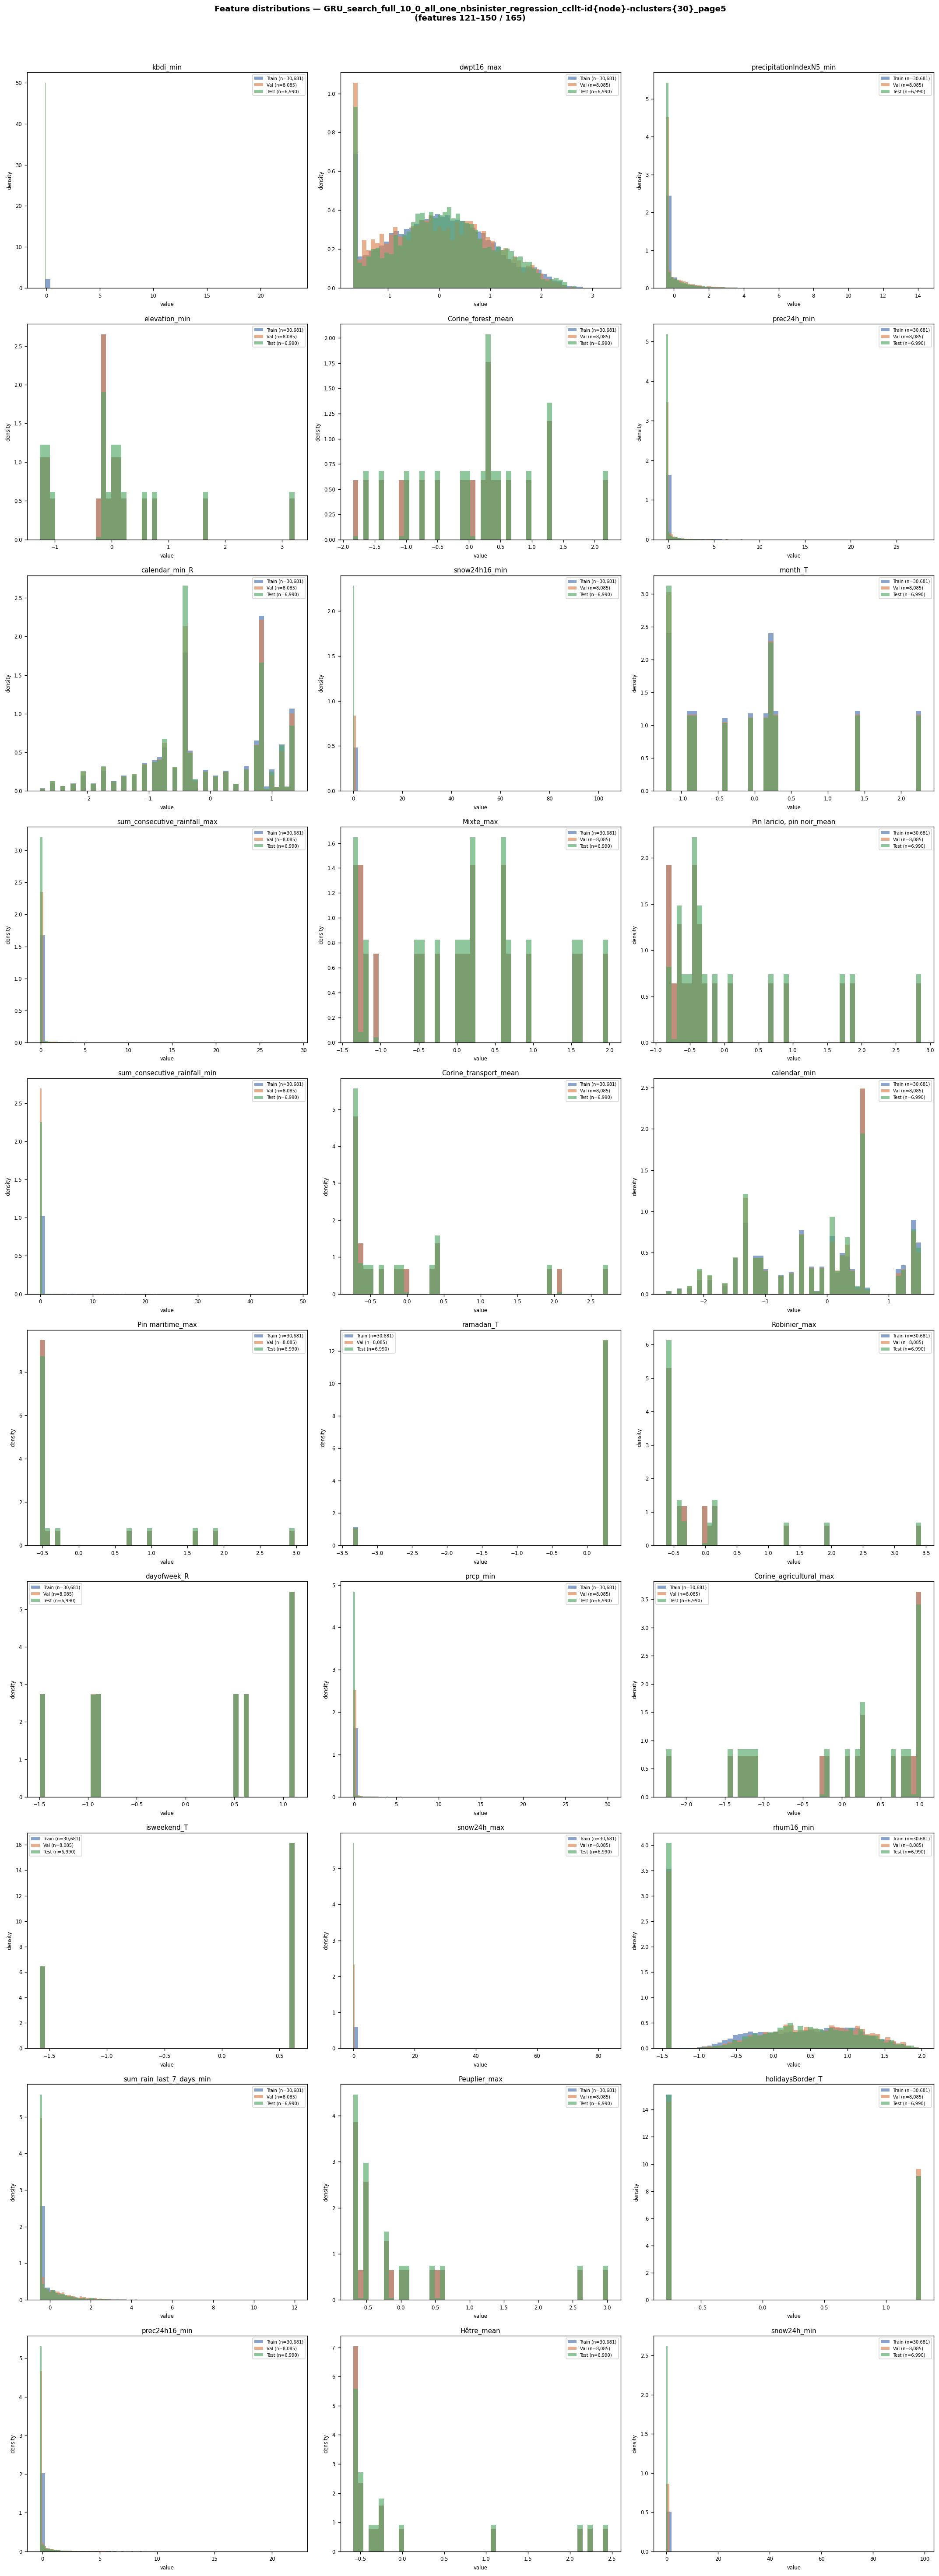

  Saved → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}_distributions_page5.png


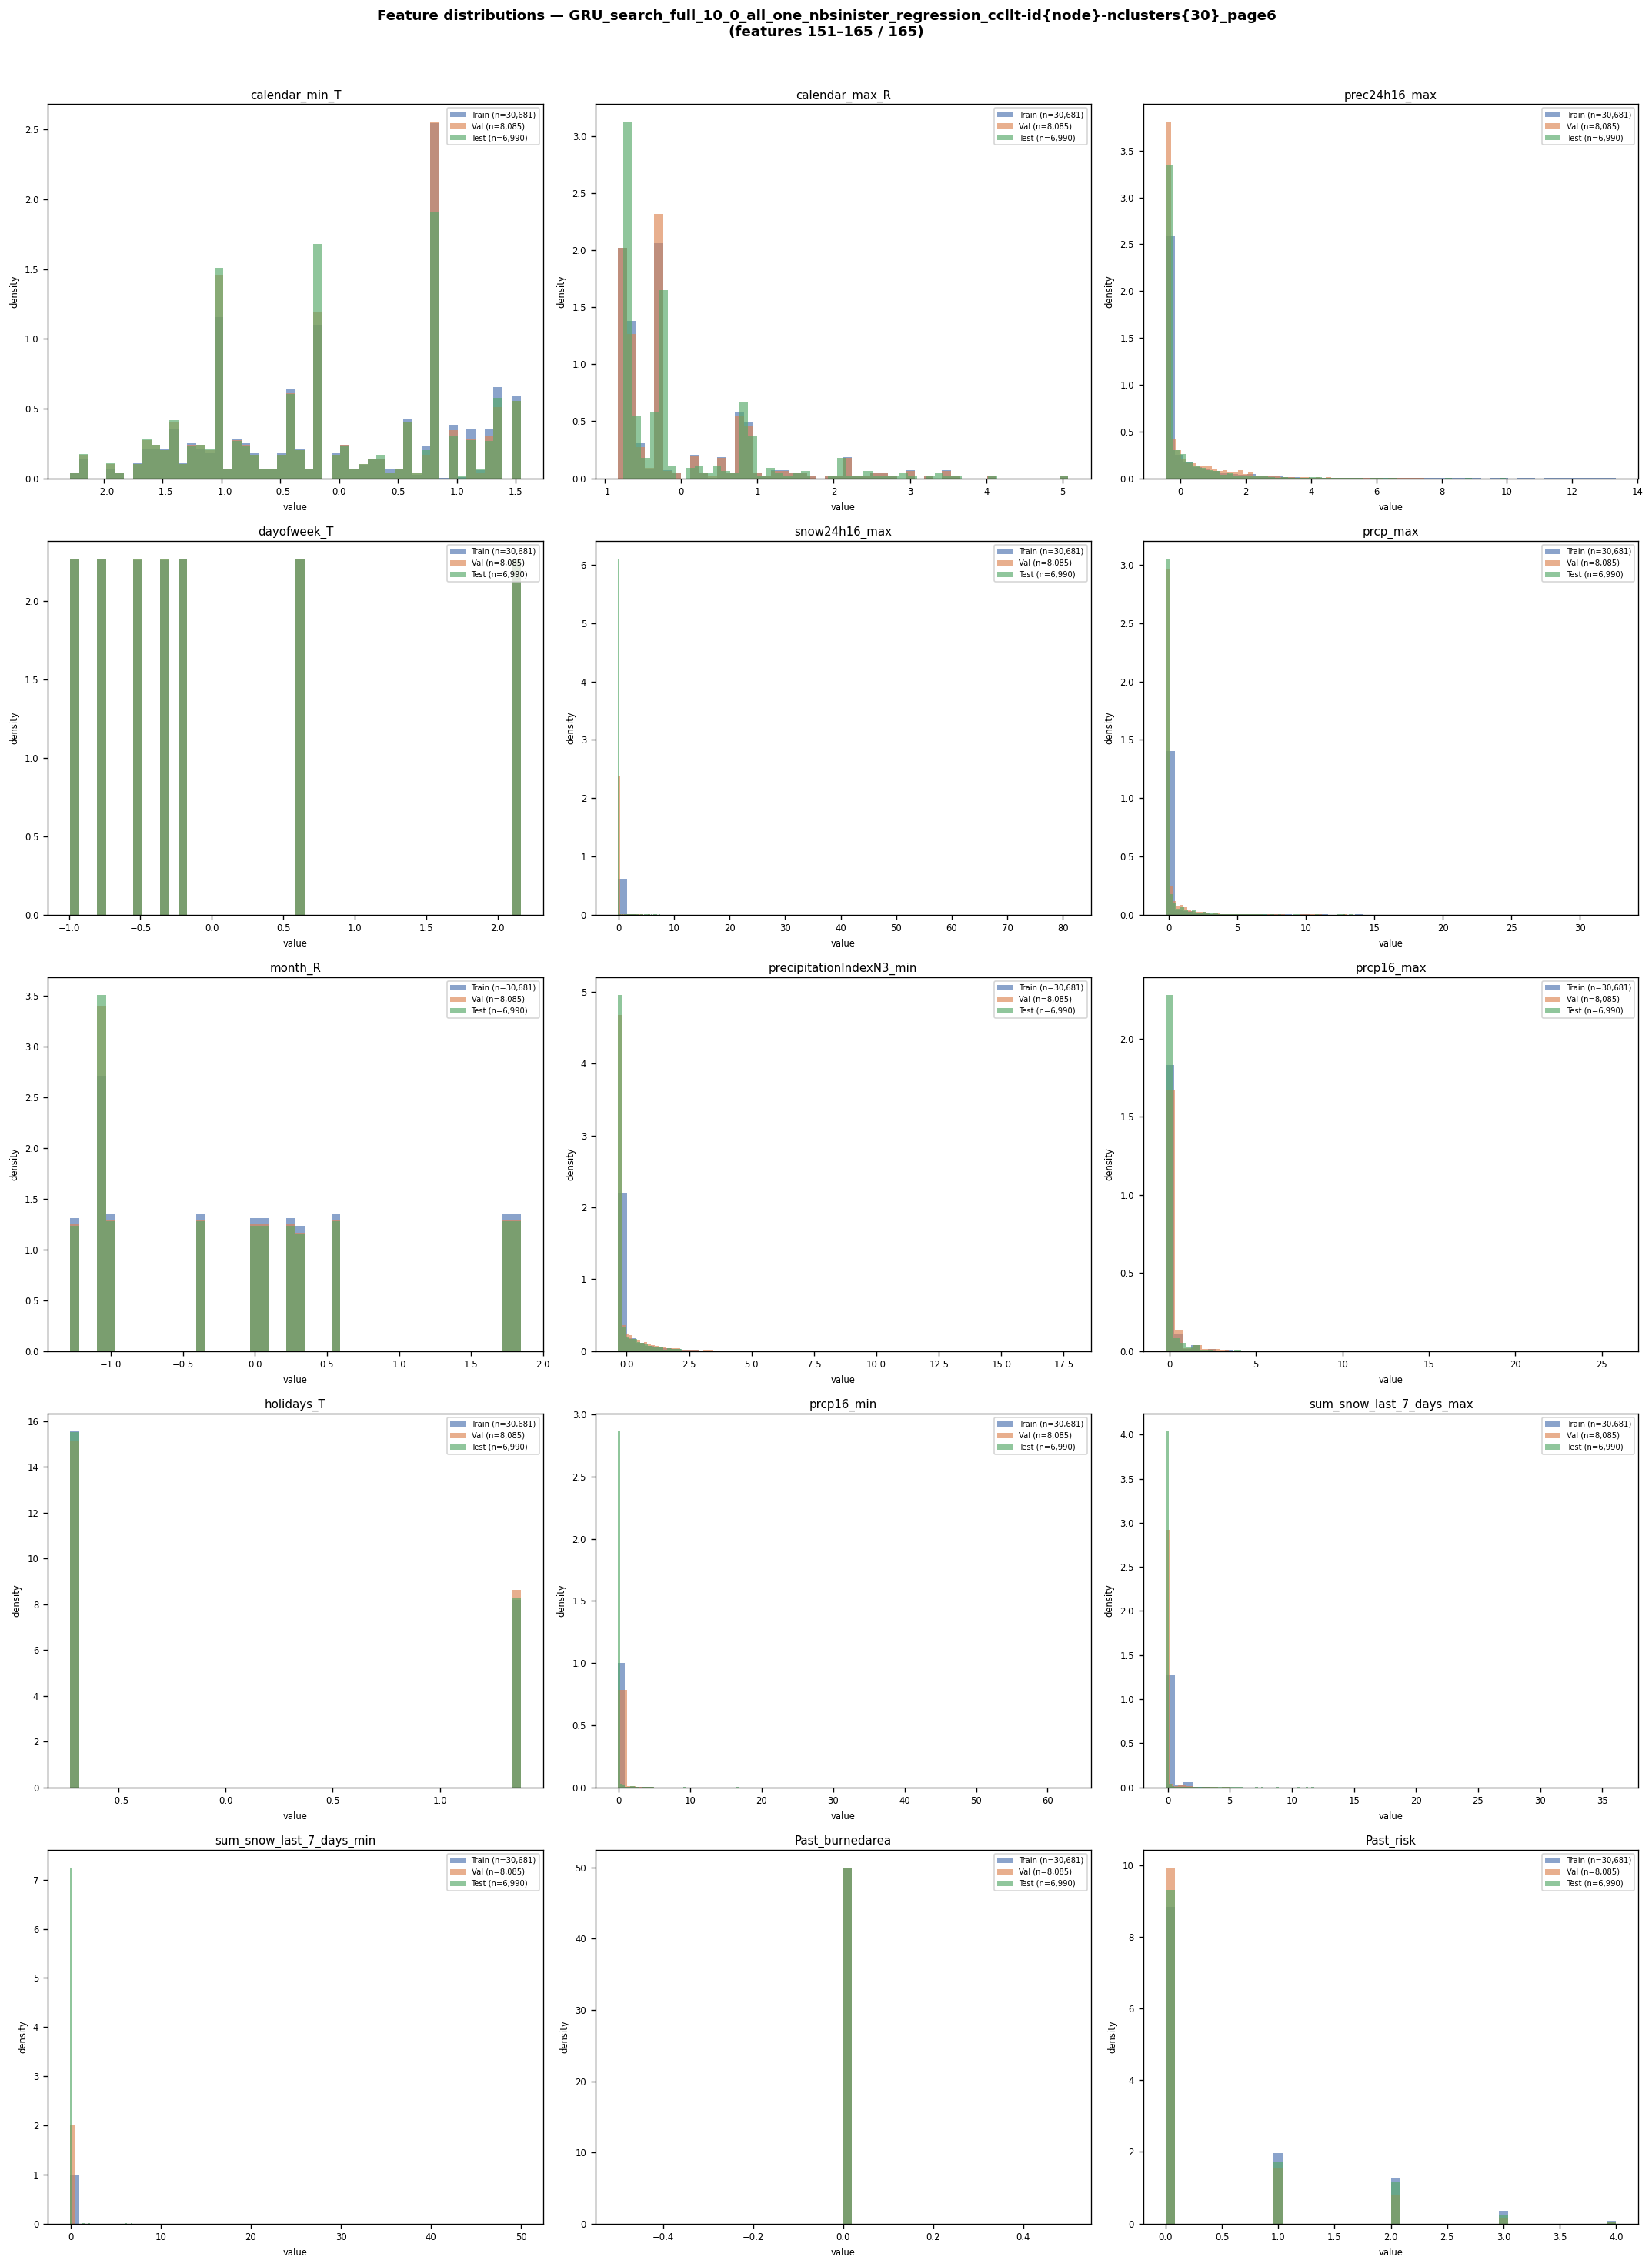

  Saved → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}_distributions_page6.png
  Summary stats saved → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}_summary_stats.csv


All models processed.


In [17]:
# Output directory (sibling of NODE_ROOT)
out_dir = ensure_dir(Path(NODE_ROOT).parent / OUTPUT_FOLDER_NAME)
print(f"Plots will be saved to: {out_dir}\n")

all_stats = []  # collect per-model summary tables

for model_name in MODEL_NAMES:
    print(f"{'='*70}")
    print(f"Model: {model_name}")
    print(f"{'='*70}")

    # ── 1. Load model ────────────────────────────────────────────────────────
    try:
        model = load_model(model_name, NODE_ROOT)
    except FileNotFoundError as e:
        print(f"  ERROR: {e}  → skipping")
        continue
    except Exception as e:
        print(f"  ERROR loading model: {e}  → skipping")
        import traceback; traceback.print_exc()
        continue

    # ── 2. Retrieve splits ───────────────────────────────────────────────────
    splits = get_split_dfs(model)
    for sname, df in splits.items():
        print(f"  {sname:5s}: {len(df):>8,} rows × {df.shape[1]} cols")

    # ── 3. Feature list ──────────────────────────────────────────────────────
    features = get_feature_columns(model, splits)
    print(f"\n  → {len(features)} feature(s) to plot")
    if not features:
        print("  WARNING: no features found – skipping plots.")
        continue

    # ── 4. Per-model output sub-folder ───────────────────────────────────────
    model_out = ensure_dir(out_dir / model_name.replace("/", "_"))

    # ── 5. Generate distribution plots ──────────────────────────────────────
    print("\n  Generating distribution plots …")
    saved = plot_feature_distributions(
        splits, features, model_name, model_out
    )

    # ── 6. Summary statistics table ─────────────────────────────────────────
    stats_df = summary_stats(splits, features)
    stats_df["model"] = model_name
    all_stats.append(stats_df)

    stats_path = model_out / f"{model_name}_summary_stats.csv"
    stats_df.to_csv(stats_path, index=False)
    print(f"  Summary stats saved → {stats_path}")

    print()

print("\nAll models processed.")

## Global summary table

In [18]:
if all_stats:
    combined = pd.concat(all_stats, ignore_index=True)
    global_path = out_dir / "global_summary_stats.csv"
    combined.to_csv(global_path, index=False)
    print(f"Global summary saved → {global_path}")
    display(combined.head(40))
else:
    print("No stats to display.")

Global summary saved → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3/global_summary_stats.csv


,feature,split,n,mean,std,min,p25,median,p75,max,model
0,Corine_transport_max,train,30681,-0.0000,1.0000,-1.0773,-0.9571,-0.0433,0.5927,2.7883,GRU_search_full_10_0_all_one_nbsinister_regres...
1,Corine_transport_max,val,8085,-0.0000,1.0001,-1.0773,-0.9571,-0.0433,0.5927,2.7883,GRU_search_full_10_0_all_one_nbsinister_regres...
2,Corine_transport_max,test,6990,-0.1250,0.8392,-1.0773,-1.0441,-0.0433,0.5927,2.7883,GRU_search_full_10_0_all_one_nbsinister_regres...
3,cluster_encoder,train,30681,0.0000,1.0000,-0.5684,-0.5684,-0.0060,-0.0060,4.2874,GRU_search_full_10_0_all_one_nbsinister_regres...
4,cluster_encoder,val,8085,0.0000,1.0001,-0.5684,-0.5684,-0.0060,-0.0060,4.2874,GRU_search_full_10_0_all_one_nbsinister_regres...
5,cluster_encoder,test,6990,0.0597,1.0581,-0.5684,-0.5684,-0.0060,-0.0060,4.2874,GRU_search_full_10_0_all_one_nbsinister_regres...
6,calendar_sum,train,30681,-0.0000,1.0000,-1.3323,-0.7317,-0.2399,0.2679,3.7149,GRU_search_full_10_0_all_one_nbsinister_regres...
7,calendar_sum,val,8085,-0.0265,0.9686,-1.2968,-0.7047,-0.2582,0.1934,3.6003,GRU_search_full_10_0_all_one_nbsinister_regres...
8,calendar_sum,test,6990,-0.0481,0.9706,-1.3237,-0.7064,-0.2995,0.1969,3.7814,GRU_search_full_10_0_all_one_nbsinister_regres...
9,Pins mélangés_mean,train,30681,-0.0000,1.0000,-0.4869,-0.4869,-0.4520,-0.1480,3.4431,GRU_search_full_10_0_all_one_nbsinister_regres...


## Optional: KS-test between train and test for each feature

In [19]:
ks_rows = []

for model_name in MODEL_NAMES:
    try:
        model = load_model(model_name, NODE_ROOT)
    except Exception:
        continue
    splits   = get_split_dfs(model)
    features = get_feature_columns(model, splits)

    if "train" not in splits or "test" not in splits:
        continue

    df_tr = splits["train"]
    df_te = splits["test"]

    for feat in features:
        if feat not in df_tr.columns or feat not in df_te.columns:
            continue
        a = df_tr[feat].dropna().values
        b = df_te[feat].dropna().values
        if len(a) < 5 or len(b) < 5:
            continue
        ks_stat, ks_pval = stats.ks_2samp(a, b)
        ks_rows.append({
            "model":   model_name,
            "feature": feat,
            "ks_stat": round(ks_stat, 4),
            "p_value": round(ks_pval, 4),
            "shift":   "YES" if ks_pval < 0.05 else "no",
        })

if ks_rows:
    ks_df = pd.DataFrame(ks_rows).sort_values("ks_stat", ascending=False)
    ks_path = out_dir / "ks_train_vs_test.csv"
    ks_df.to_csv(ks_path, index=False)
    print(f"KS results saved → {ks_path}")
    display(ks_df.head(200))
else:
    print("No KS results computed.")

  Loading /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}.pkl … OK
KS results saved → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3/ks_train_vs_test.csv


,model,feature,ks_stat,p_value,shift
72,GRU_search_full_10_0_all_one_nbsinister_regres...,NDMI_max,0.1589,0.0,YES
49,GRU_search_full_10_0_all_one_nbsinister_regres...,departement_encoder,0.1343,0.0,YES
131,GRU_search_full_10_0_all_one_nbsinister_regres...,"Pin laricio, pin noir_mean",0.1268,0.0,YES
55,GRU_search_full_10_0_all_one_nbsinister_regres...,Corine_urban_max,0.1194,0.0,YES
73,GRU_search_full_10_0_all_one_nbsinister_regres...,id_encoder,0.1194,0.0,YES
...,...,...,...,...,...
127,GRU_search_full_10_0_all_one_nbsinister_regres...,snow24h16_min,0.0004,1.0,no
28,GRU_search_full_10_0_all_one_nbsinister_regres...,dayofweek,0.0004,1.0,no
146,GRU_search_full_10_0_all_one_nbsinister_regres...,holidaysBorder_T,0.0003,1.0,no
141,GRU_search_full_10_0_all_one_nbsinister_regres...,isweekend_T,0.0000,1.0,no


## Land Cover Feature Analysis over Time

Investigate if features meant to be static (like Corine Land Cover means) are truly stable over time and across departments.


Processing GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30} for time-series analysis...
  Loading /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}.pkl … OK


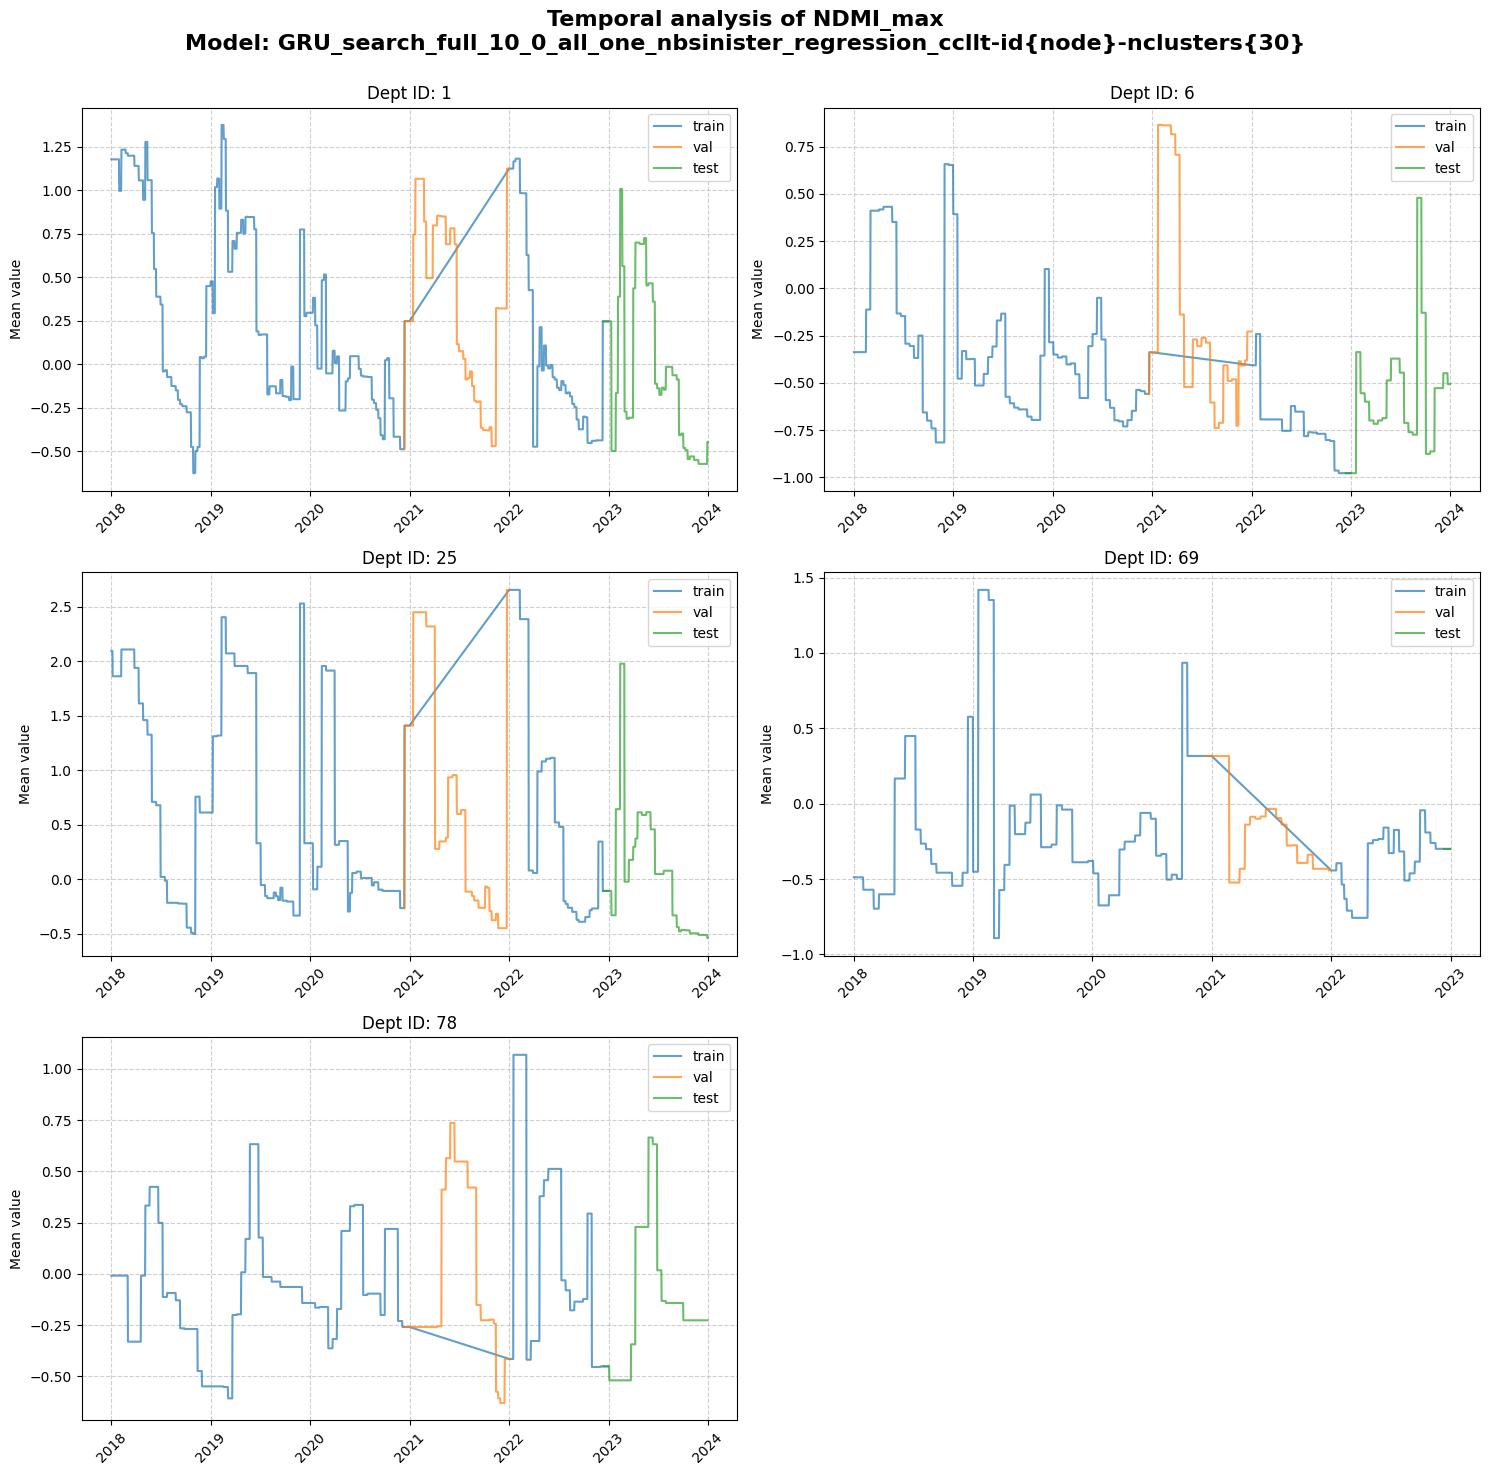

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/NDMI_max_time_series.png


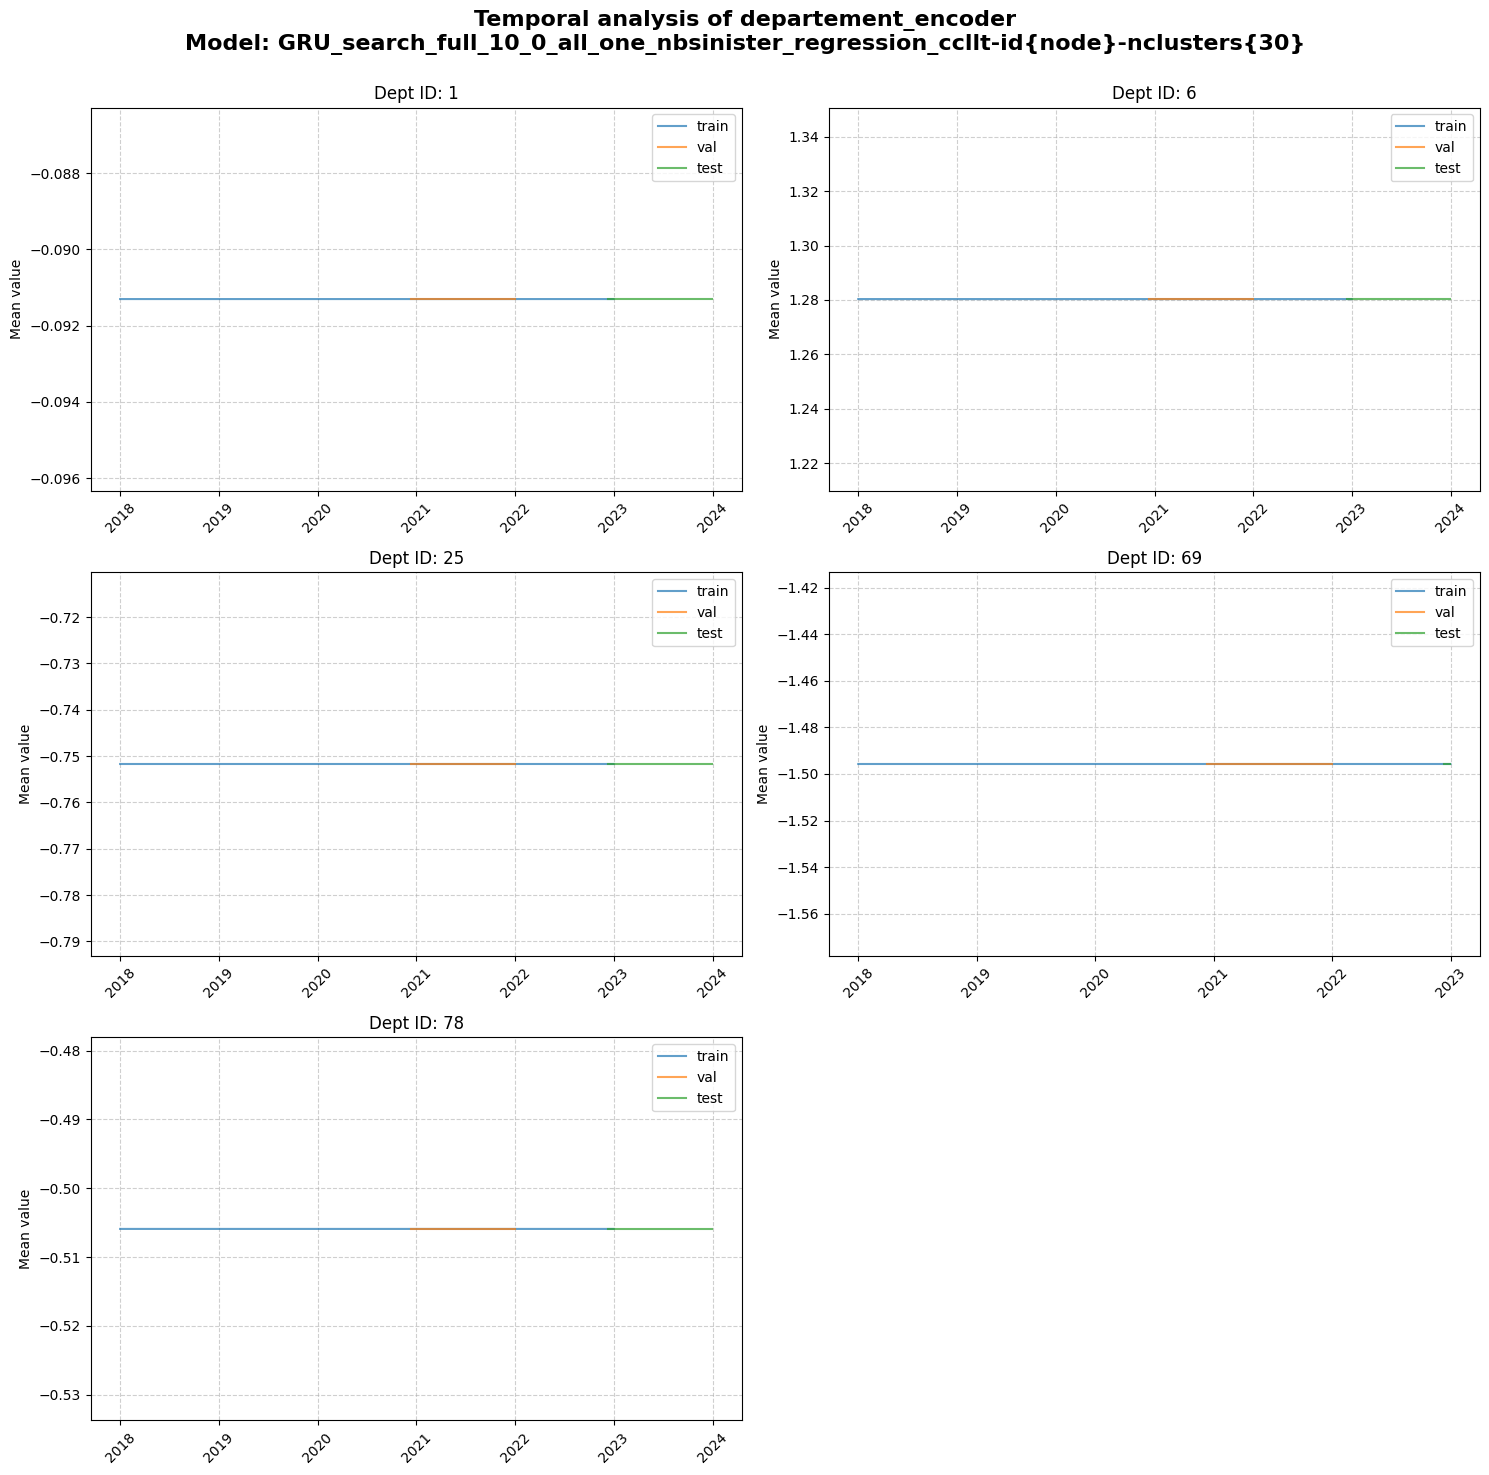

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/departement_encoder_time_series.png


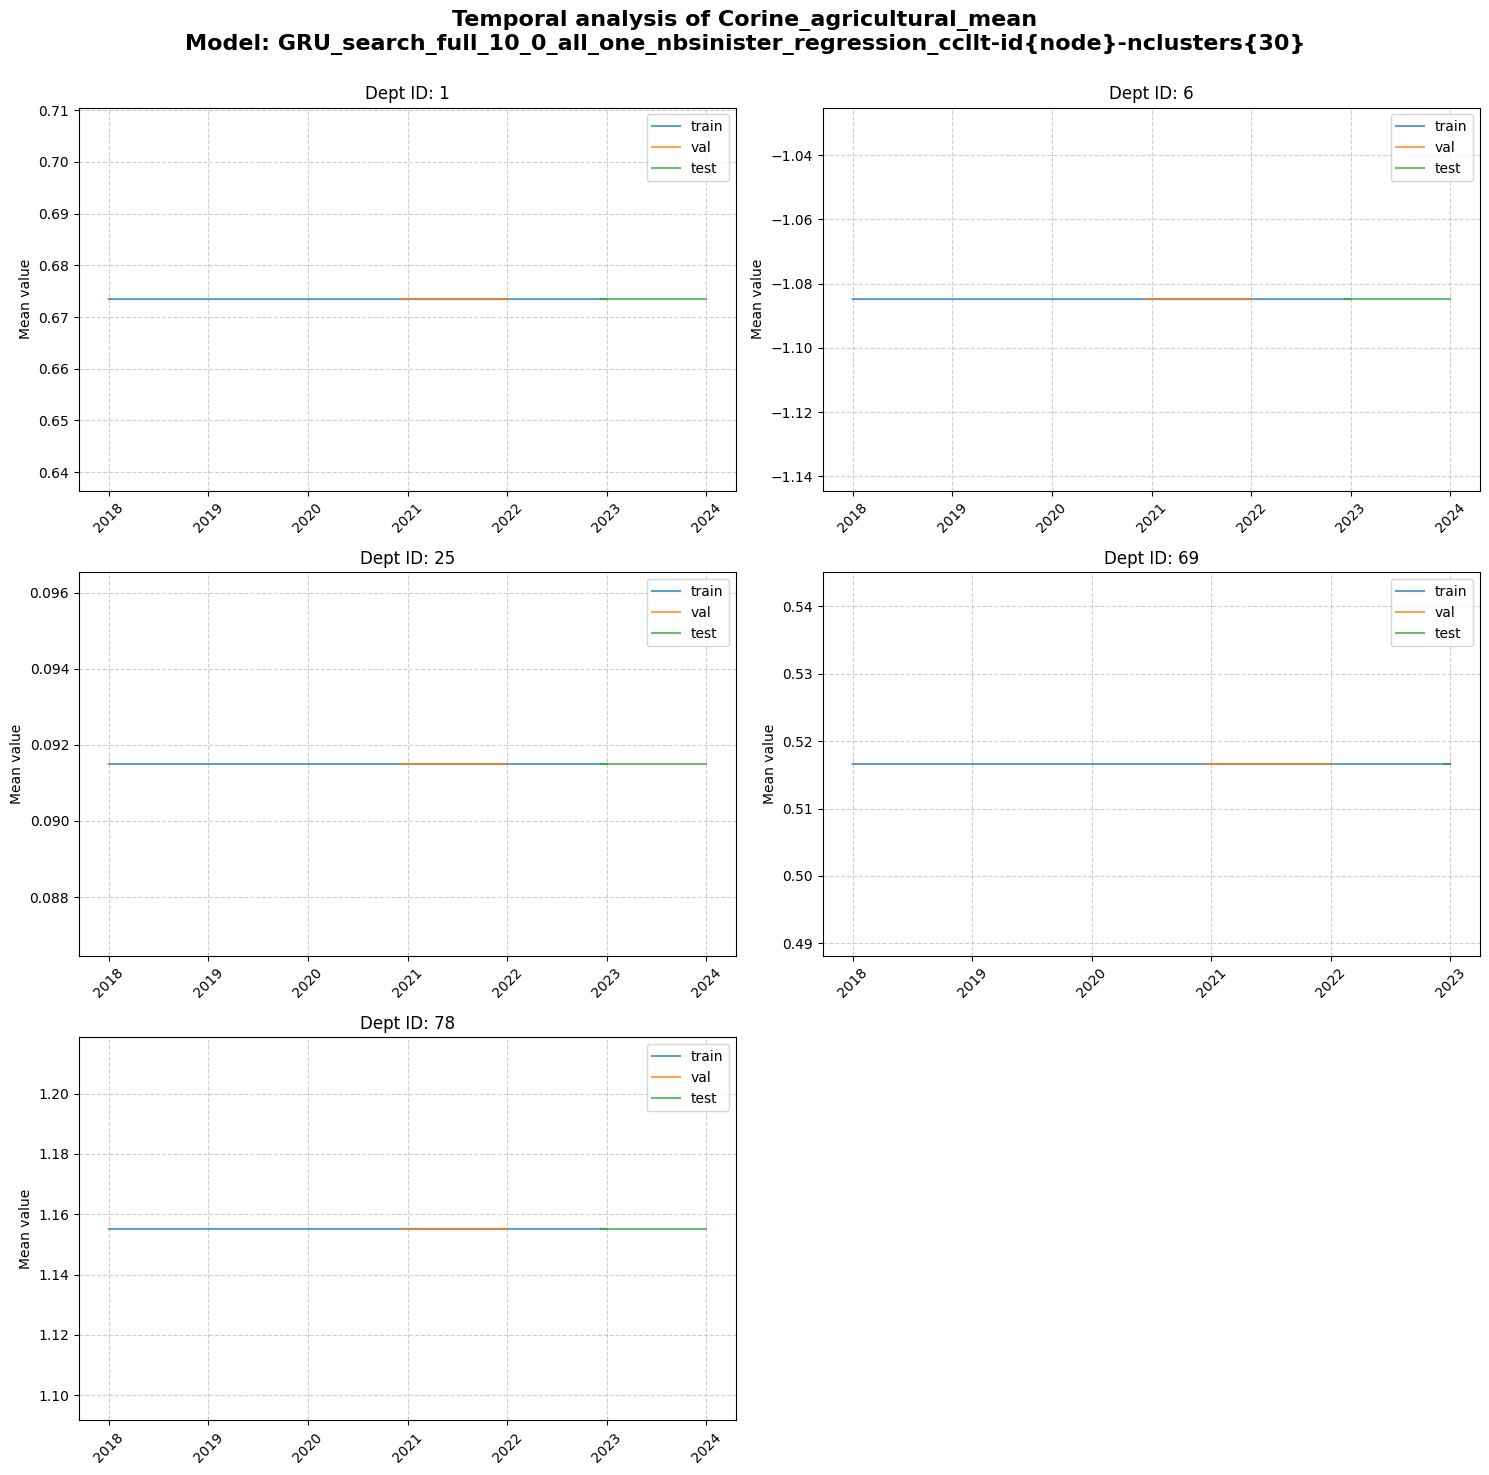

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/Corine_agricultural_mean_time_series.png


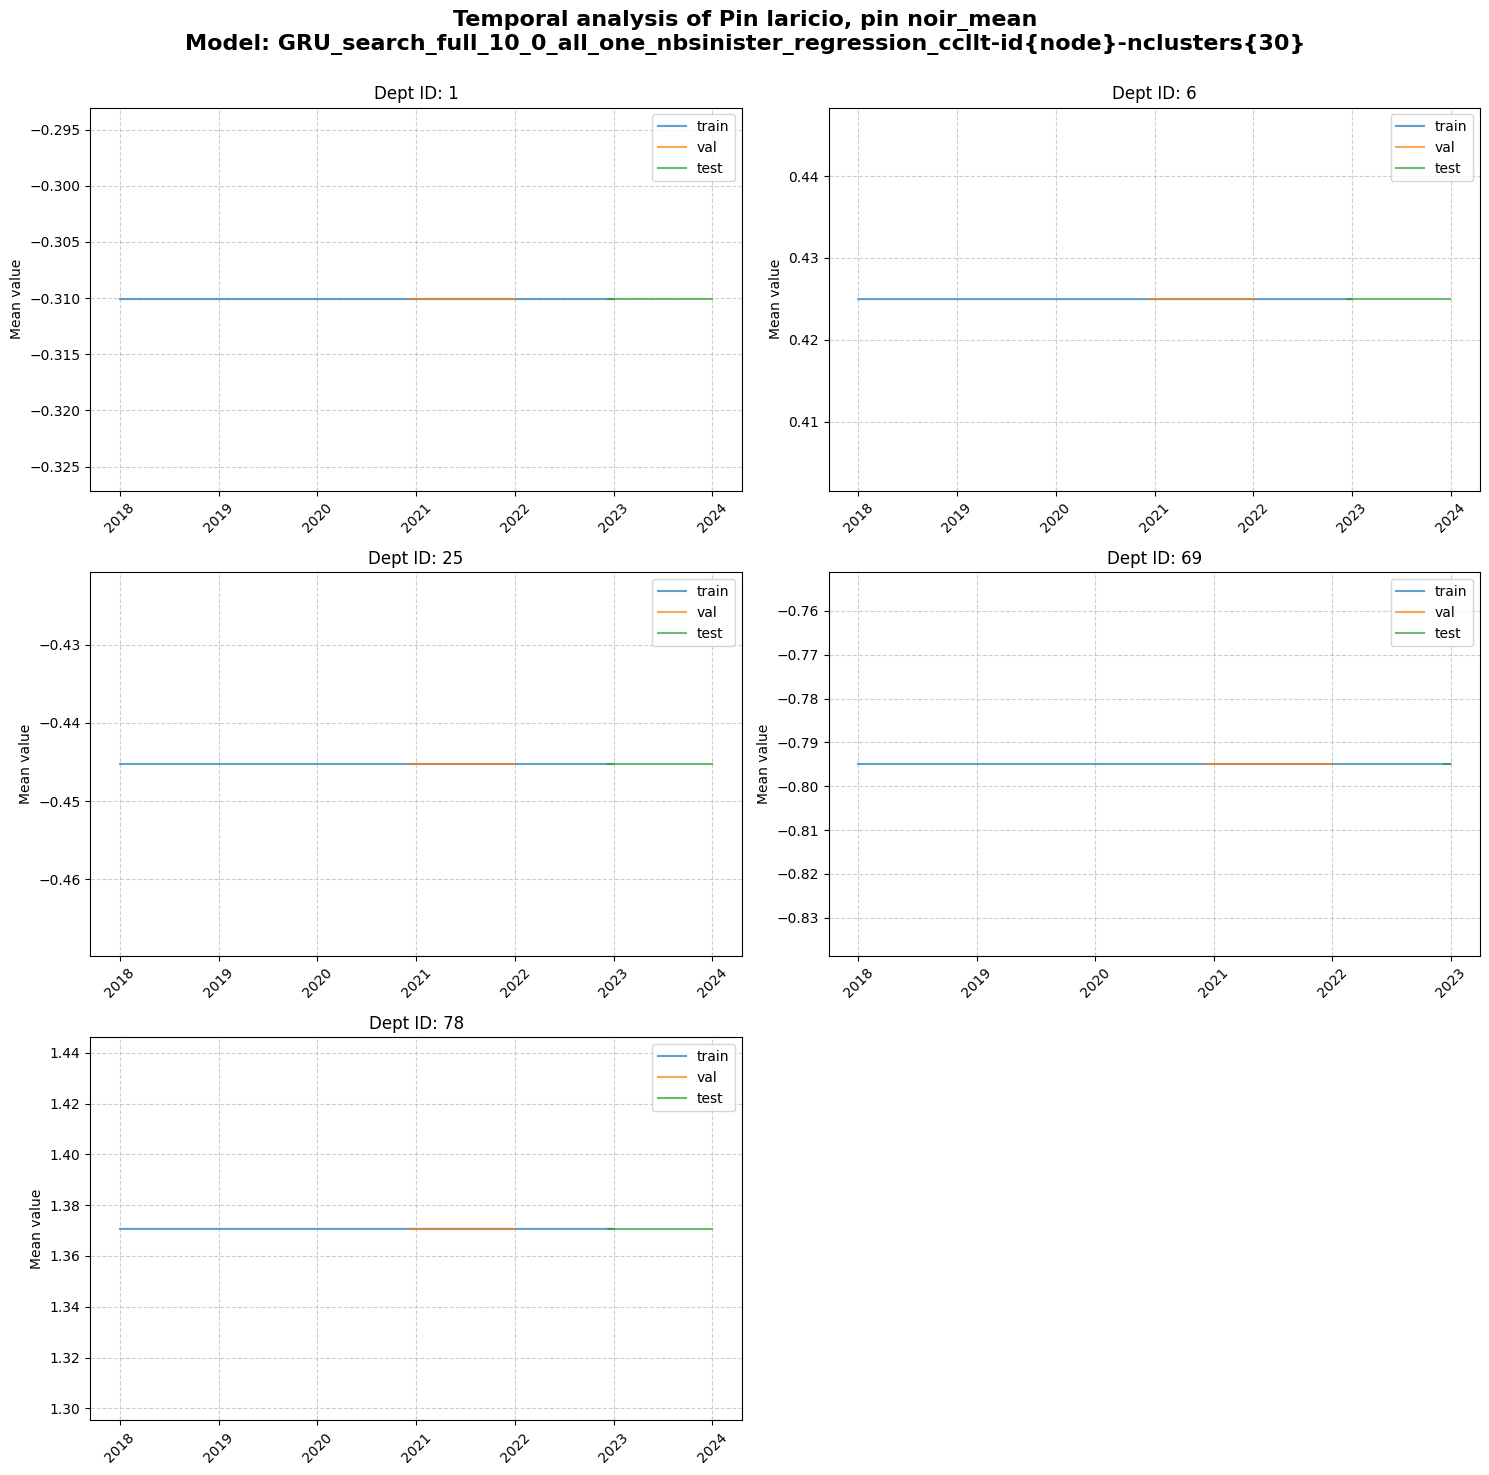

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/Pin_laricio_pin_noir_mean_time_series.png


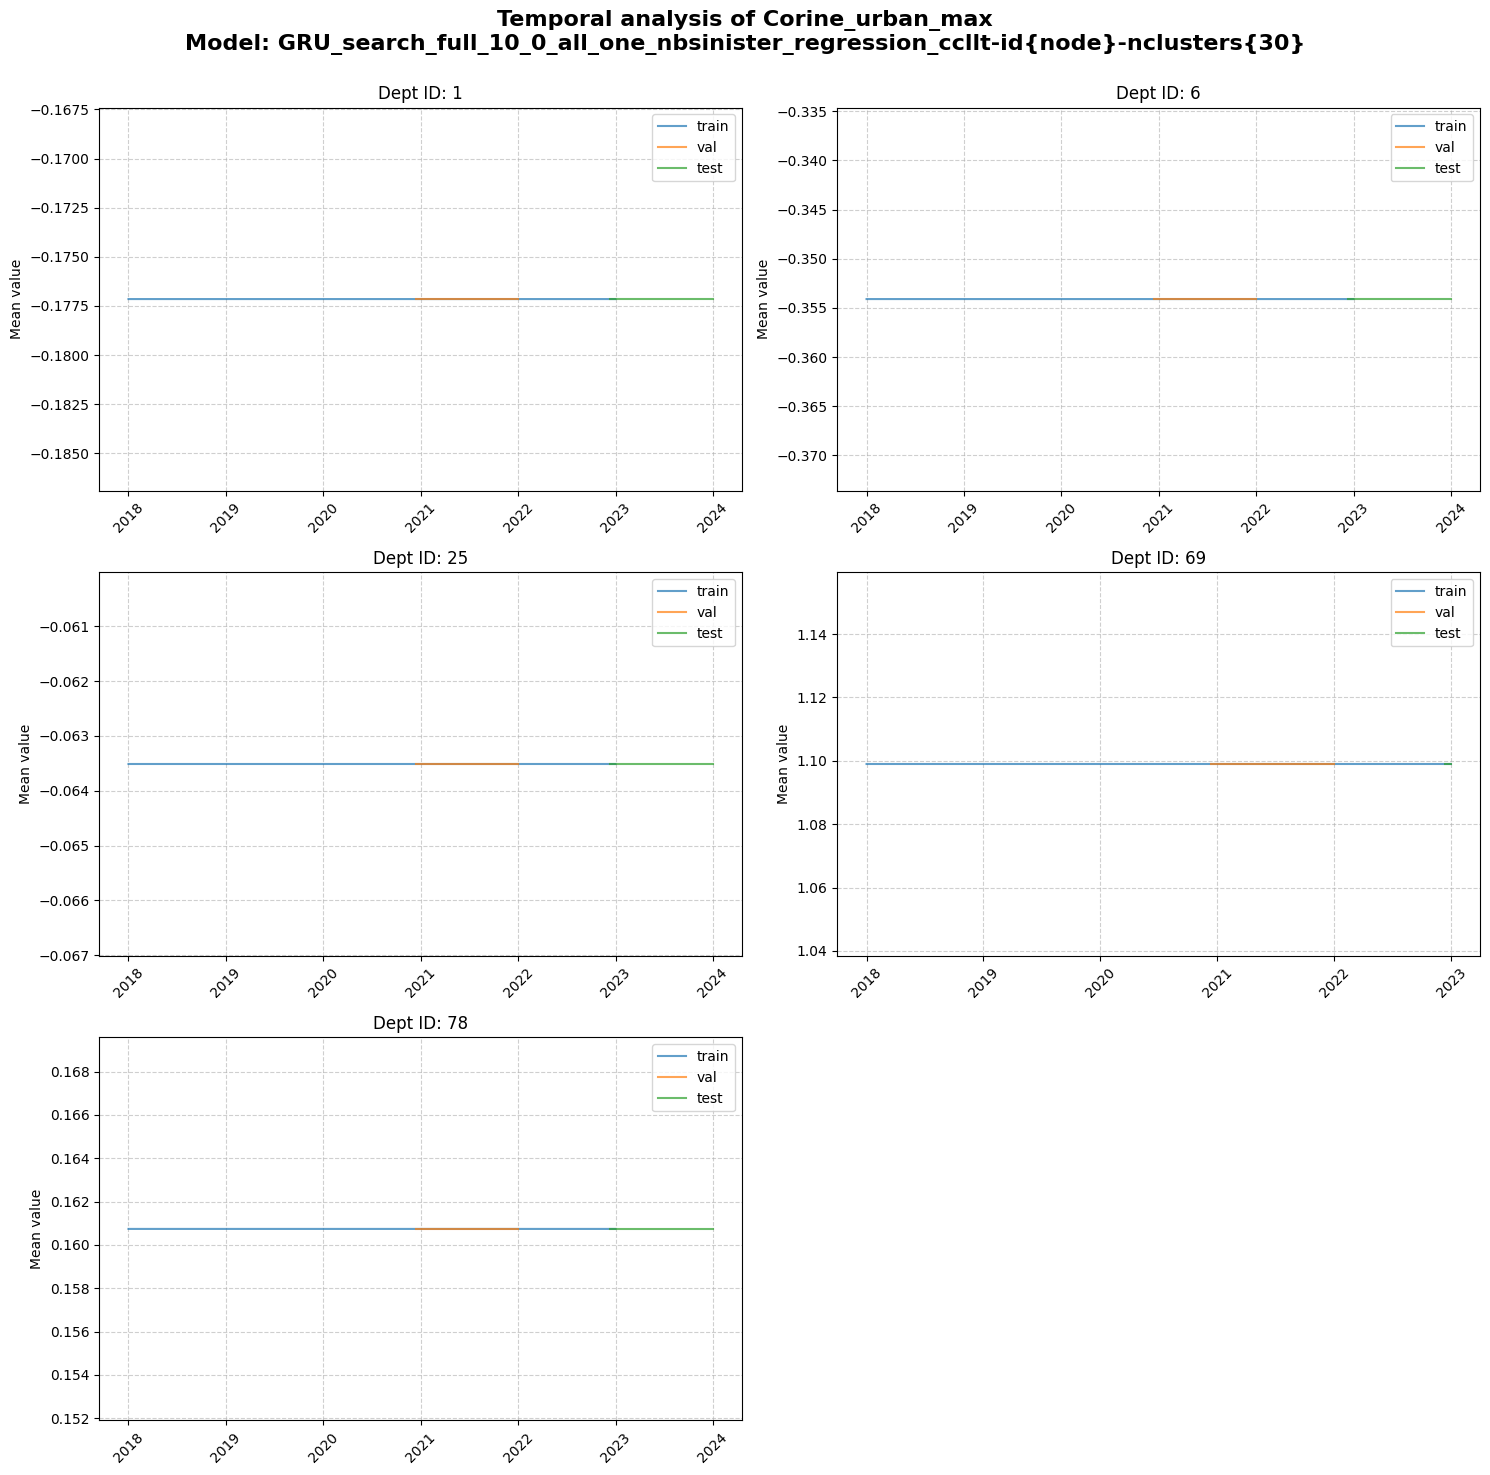

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/Corine_urban_max_time_series.png


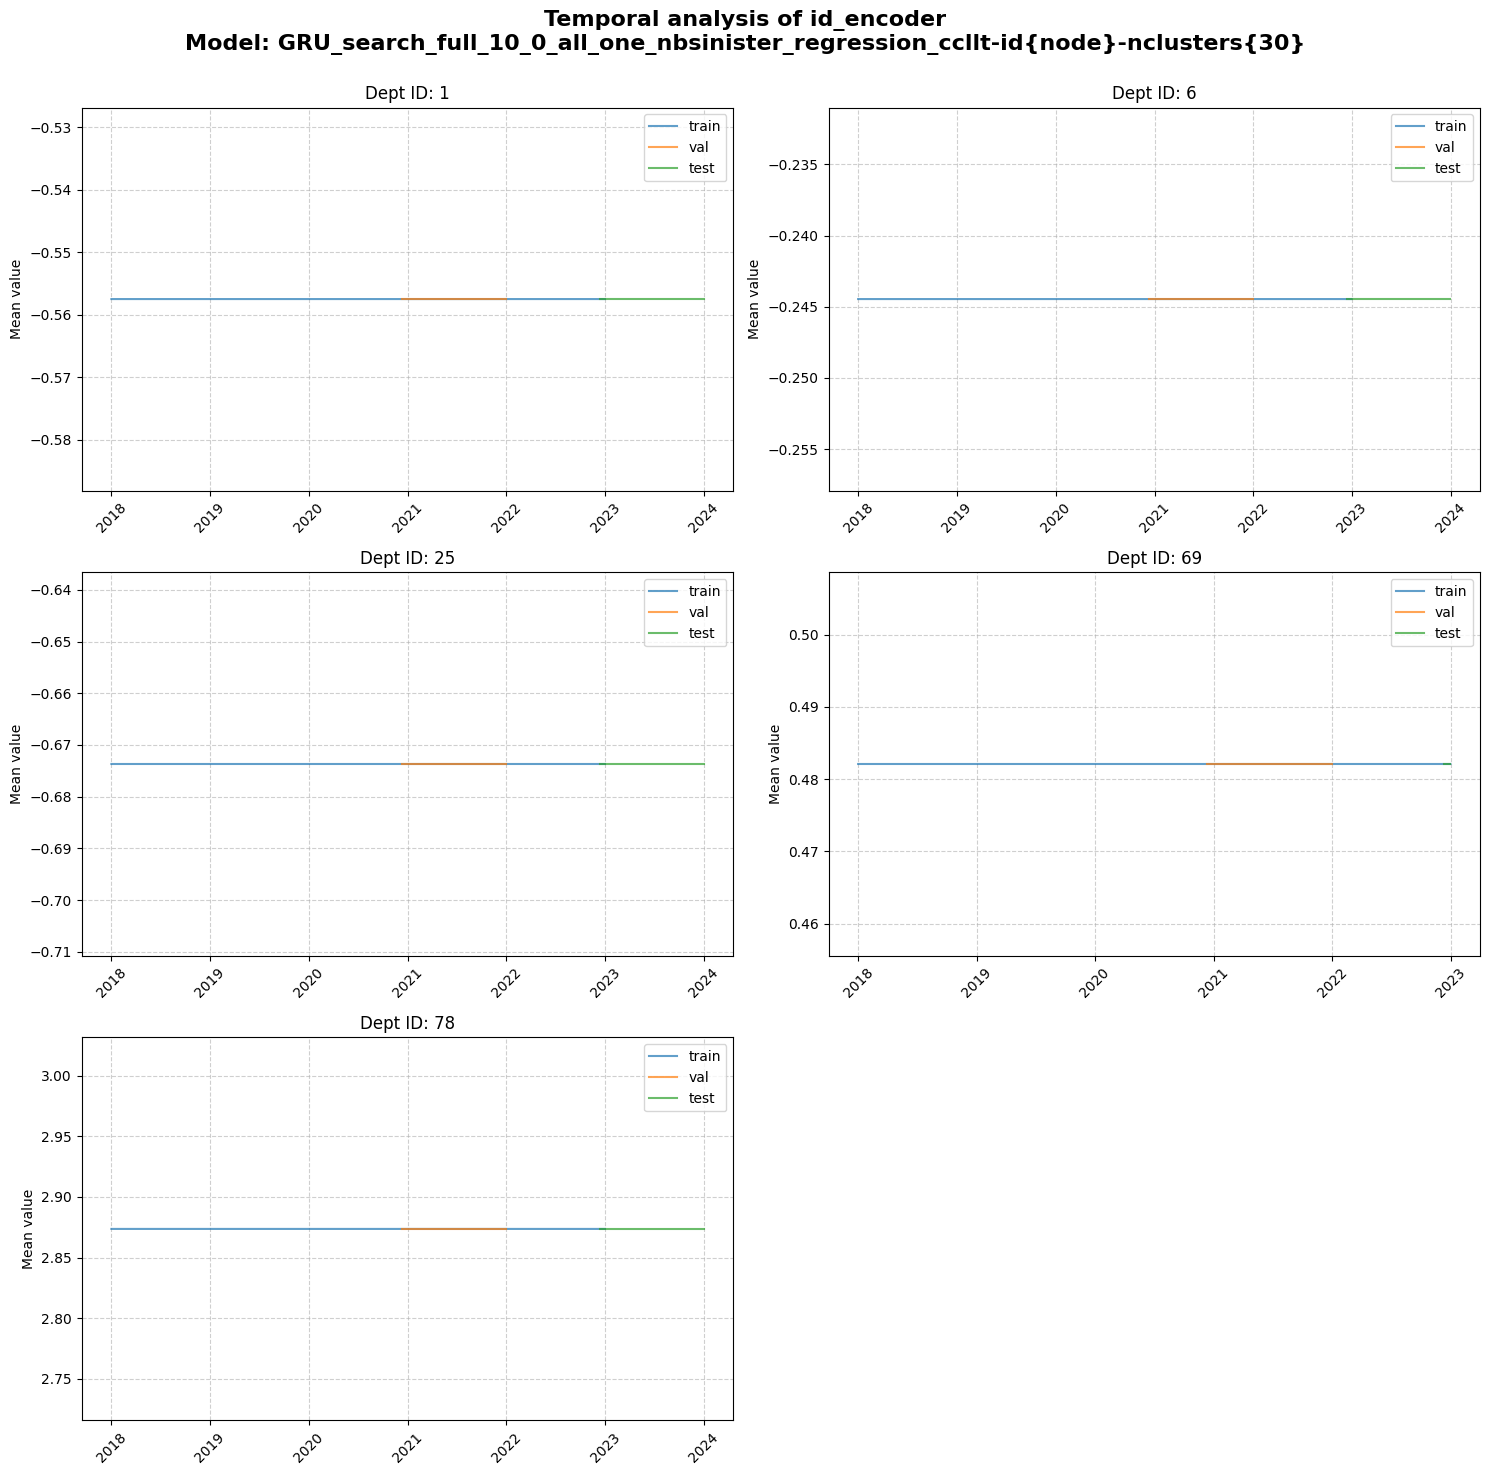

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/id_encoder_time_series.png


In [20]:
def plot_feature_time_series_by_dept(splits: dict, features_to_plot: list, out_dir: Path, model_name: str):
    """
    Plot the mean value of specified features over time, grouped by department.
    Useful for checking if land cover features (like Corine_forest_mean) are truly static.
    """
    import matplotlib.pyplot as plt
    import pandas as pd
    try:
        from tools import allDates
    except ImportError:
        allDates = None
    
    # Combined dataframe for visualization
    all_dfs = []
    for split_name, df in splits.items():
        # Ensure we have the necessary columns
        if 'date' not in df.columns:
            continue
        
        # Identify department column
        dept_col = None
        for col in ['departement', 'departement_encoder']:
            if col in df.columns:
                dept_col = col
                break
        
        if dept_col is None:
            continue
            
        temp_df = df[['date', dept_col] + [f for f in features_to_plot if f in df.columns]].copy()
        temp_df['split'] = split_name
        all_dfs.append(temp_df)
    
    if not all_dfs:
        print("  Warning: Required columns (date, departement) not found in splits. Skipping time-series plots.")
        return []

    df_full = pd.concat(all_dfs, ignore_index=True)
    
    # Convert date to datetime if numeric
    if allDates and pd.api.types.is_integer_dtype(df_full['date']):
        df_full['date_dt'] = df_full['date'].apply(lambda x: pd.to_datetime(allDates[x]) if 0 <= x < len(allDates) else pd.NaT)
    else:
        df_full['date_dt'] = pd.to_datetime(df_full['date'])
    
    # Drop rows with invalid dates
    df_full = df_full.dropna(subset=['date_dt'])
    
    saved_paths = []
    
    for feat in features_to_plot:
        if feat not in df_full.columns:
            continue
            
        depts = sorted(df_full[dept_col].unique())
        n_depts = len(depts)
        if n_depts == 0: continue
        
        # Create subplots for each department
        ncols = 2
        nrows = (n_depts + 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows), sharex=False)
        axes = axes.flatten() if n_depts > 1 else [axes]
        
        fig.suptitle(f"Temporal analysis of {feat}\nModel: {model_name}", fontsize=16, fontweight='bold')
        
        for i, dept in enumerate(depts):
            ax = axes[i]
            dept_df = df_full[df_full[dept_col] == dept]
            
            for split in ['train', 'val', 'test']:
                split_df = dept_df[dept_df['split'] == split]
                if split_df.empty: continue
                
                # Group by date and calculate mean
                daily_mean = split_df.groupby('date_dt')[feat].mean().sort_index()
                ax.plot(daily_mean.index, daily_mean.values, label=split, alpha=0.7)
            
            ax.set_title(f"Dept ID: {dept}")
            ax.set_ylabel("Mean value")
            ax.legend()
            ax.grid(True, linestyle='--', alpha=0.6)
            plt.setp(ax.get_xticklabels(), rotation=45)
            
        # Hide empty subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        fig.tight_layout(rect=[0, 0, 1, 0.98])
        
        safe_name = feat.replace(" ", "_").replace(",", "")
        fig_path = out_dir / f"{safe_name}_time_series.png"
        fig.savefig(fig_path, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        saved_paths.append(fig_path)
        print(f"  Saved time-series plot \u2192 {fig_path}")
        
    return saved_paths

# Selection of features to investigate
static_features = [
    "NDMI_max",
    "departement_encoder",
    "Corine_agricultural_mean",
    "Pin laricio, pin noir_mean",
    "Corine_urban_max",
    "id_encoder"
]

for model_name in MODEL_NAMES:
    print(f"\nProcessing {model_name} for time-series analysis...")
    try:
        model = load_model(model_name, NODE_ROOT)
    except Exception:
        print(f"  Failed to load {model_name}")
        continue
    splits = get_split_dfs(model)
    out_dir = Path(NODE_ROOT) / model_name
    
    plot_feature_time_series_by_dept(splits, static_features, out_dir, model_name)



Processing GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30} for time-series analysis...
  Loading /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}.pkl … OK


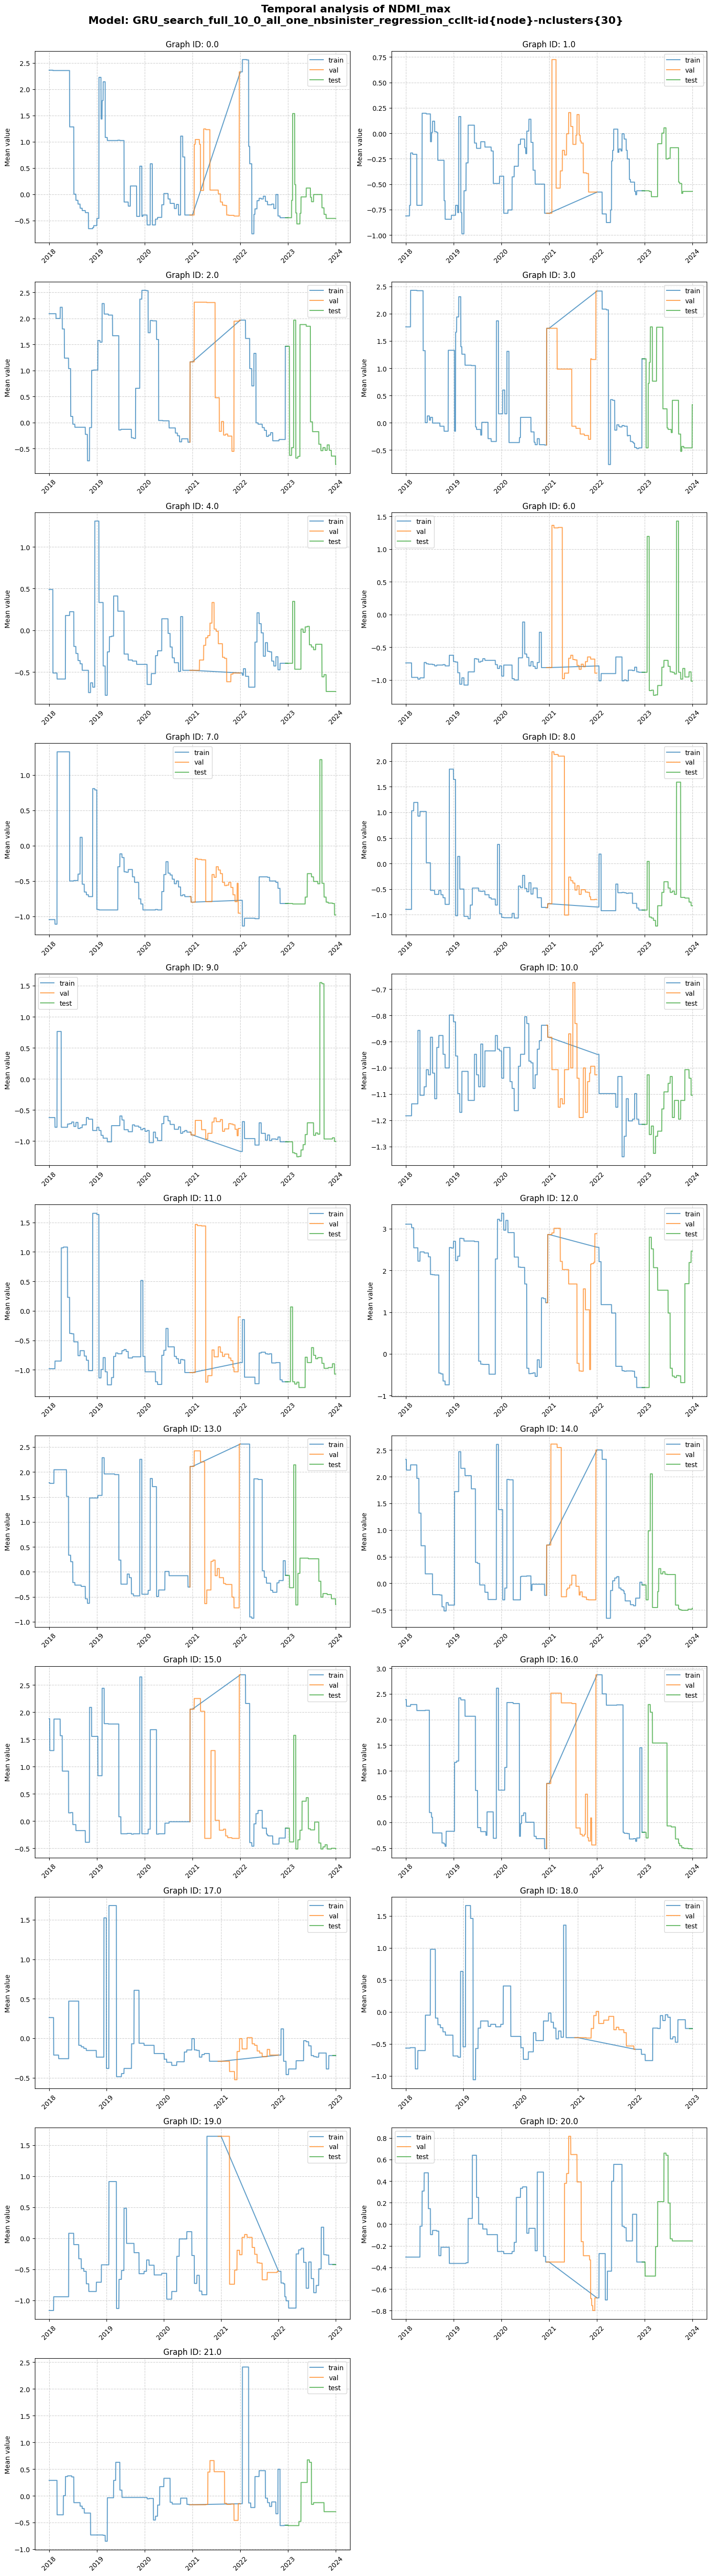

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/NDMI_max_time_series.png


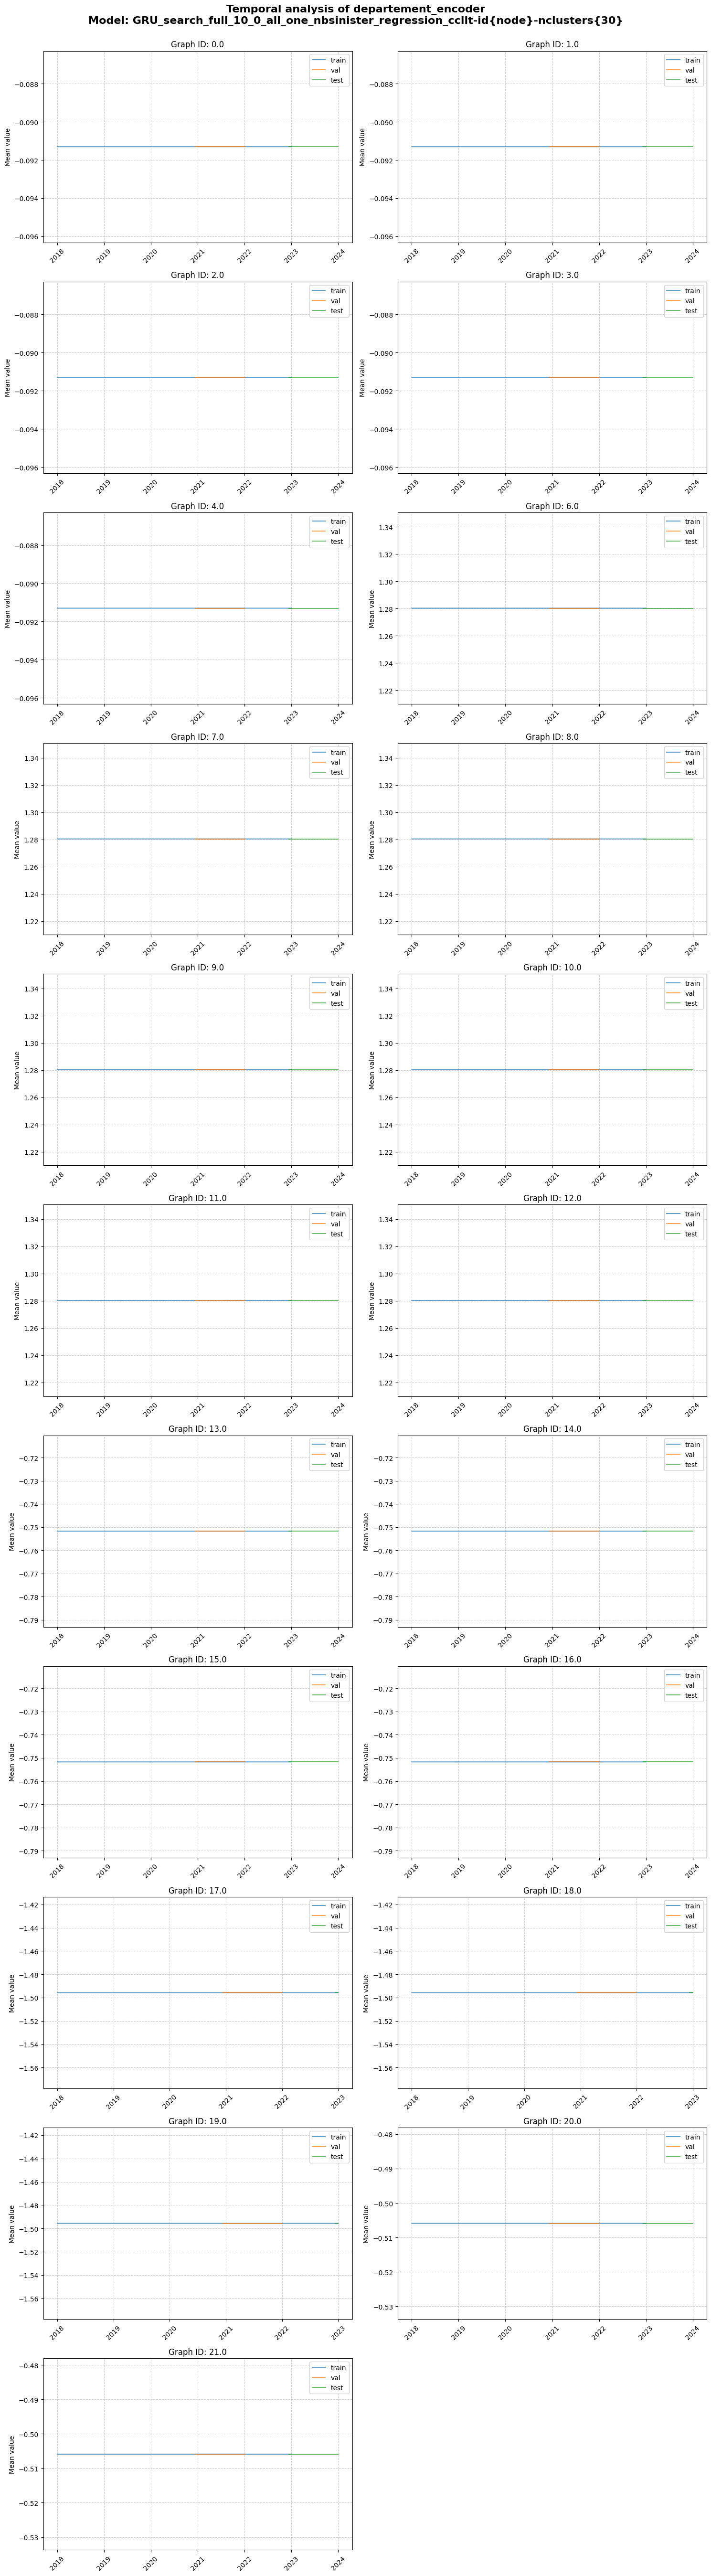

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/departement_encoder_time_series.png


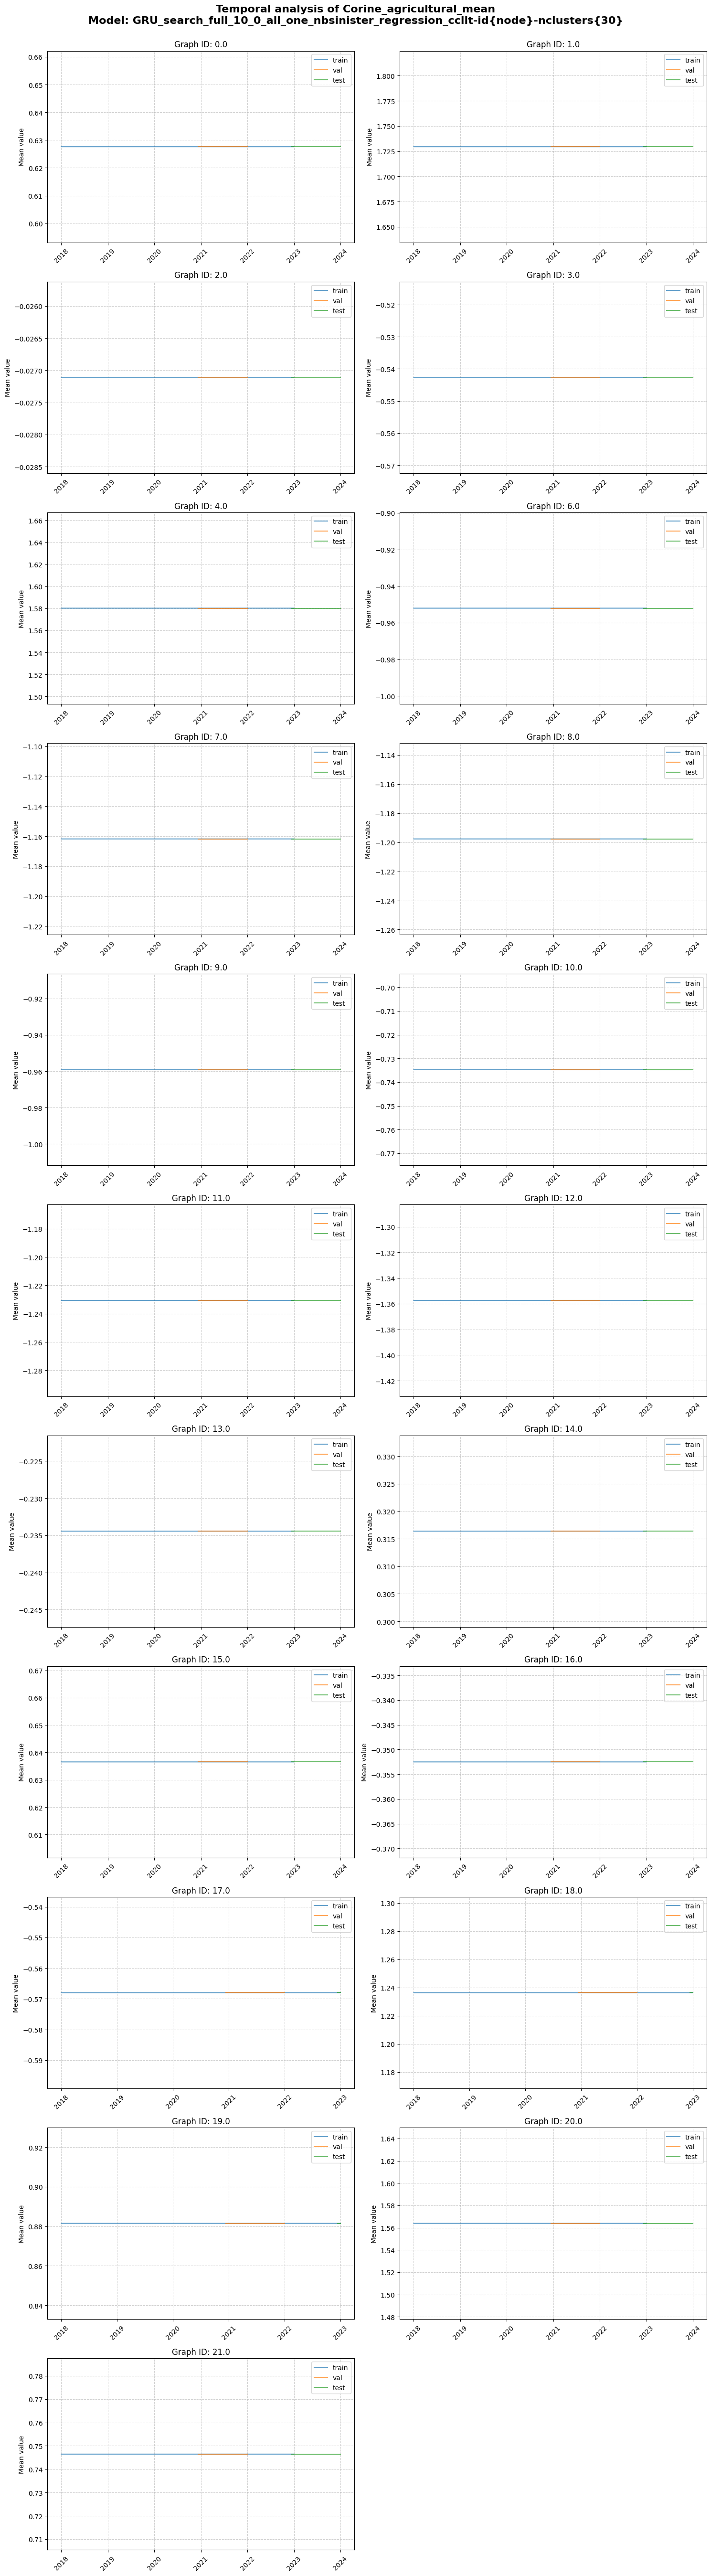

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/Corine_agricultural_mean_time_series.png


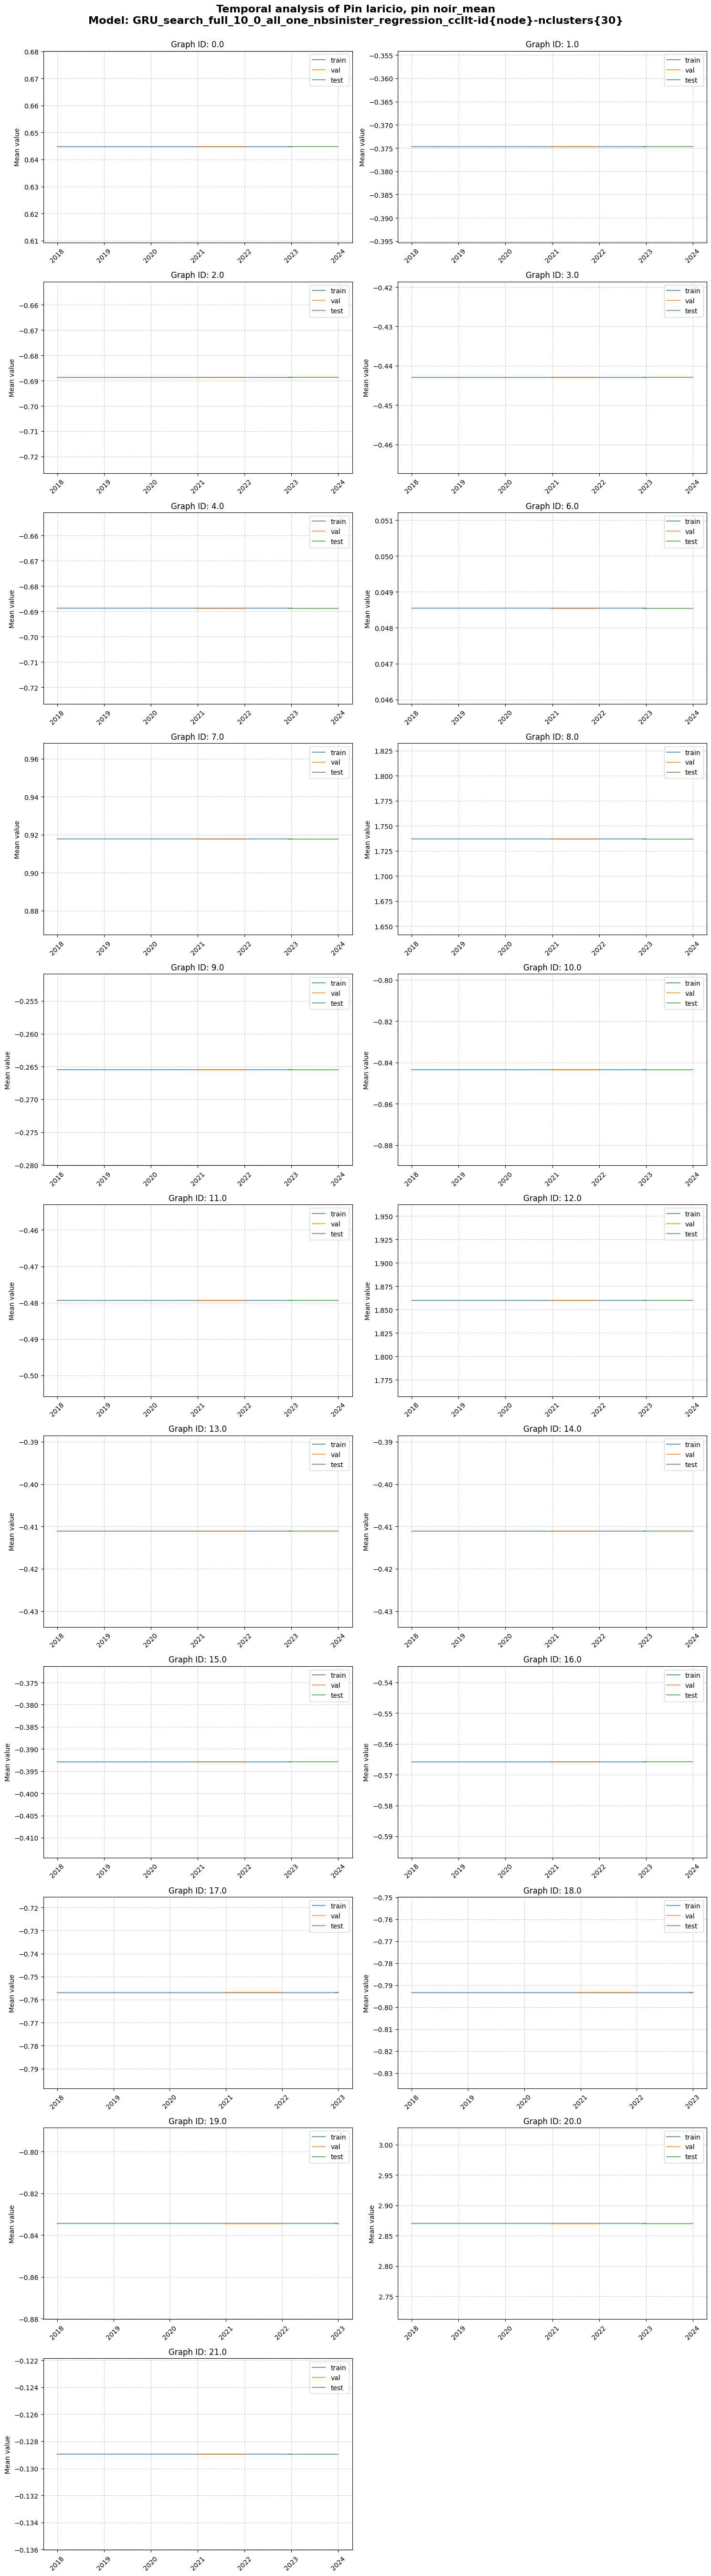

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/Pin_laricio_pin_noir_mean_time_series.png


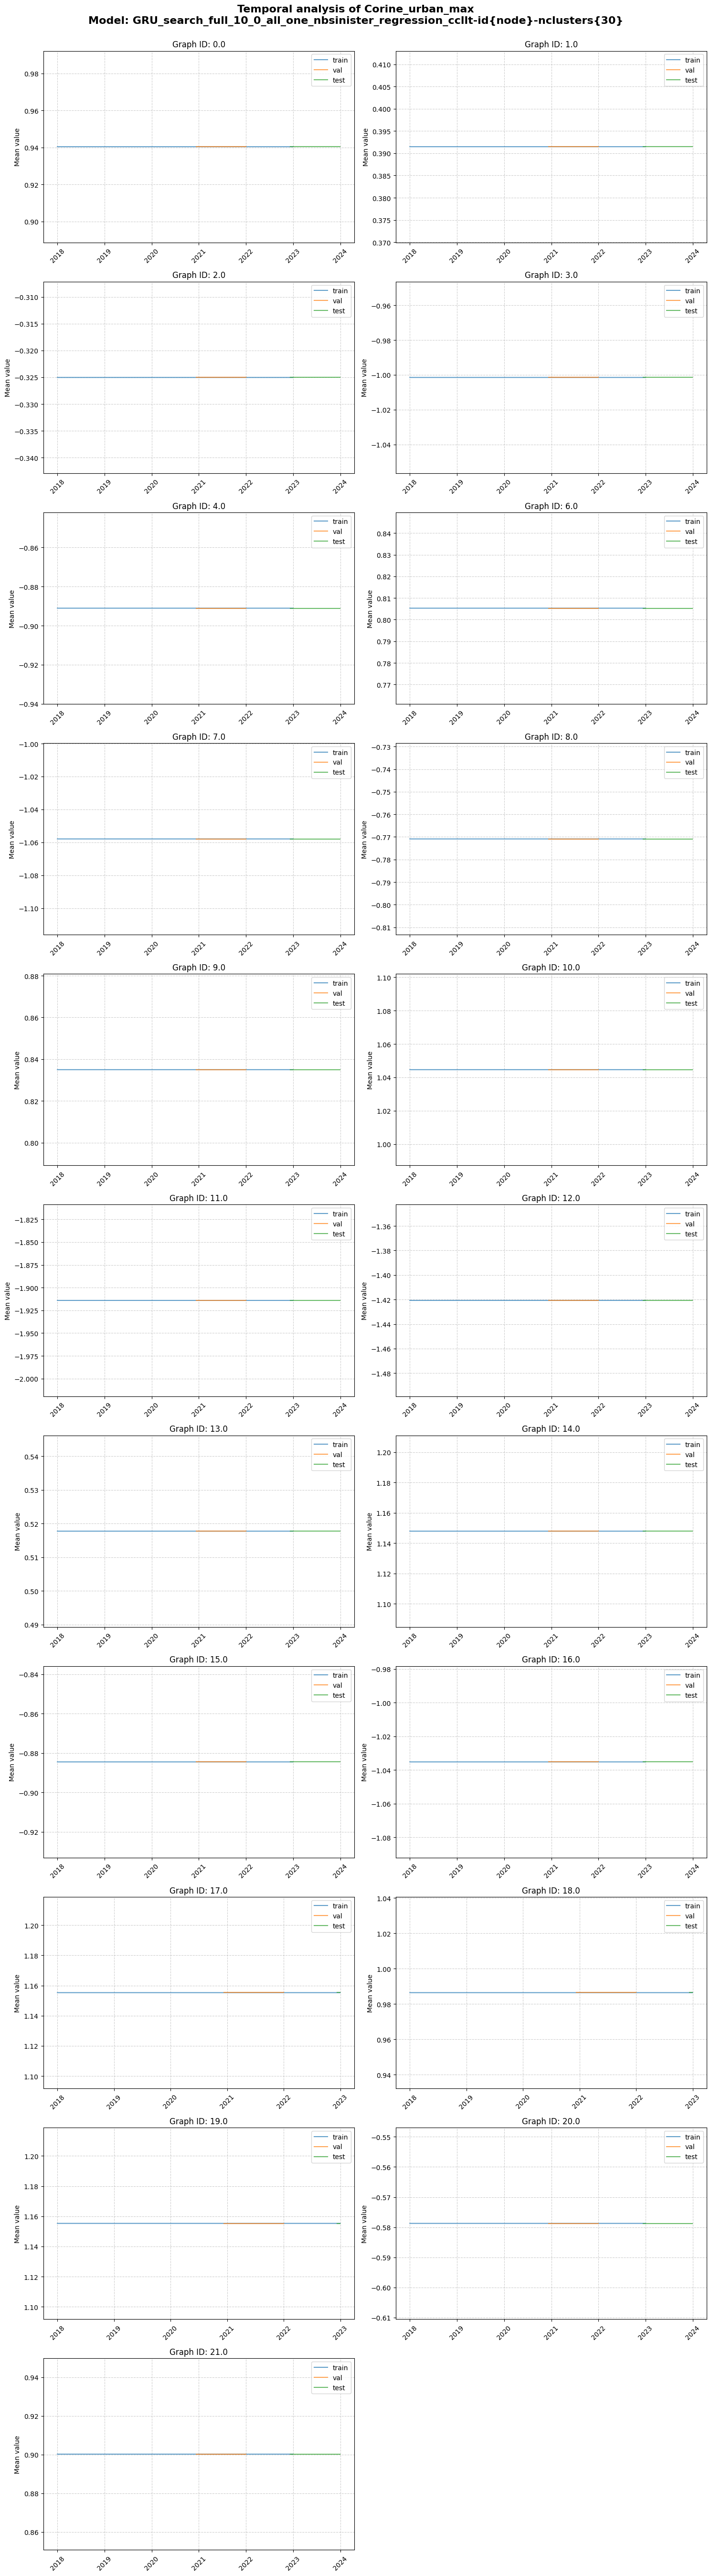

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/Corine_urban_max_time_series.png


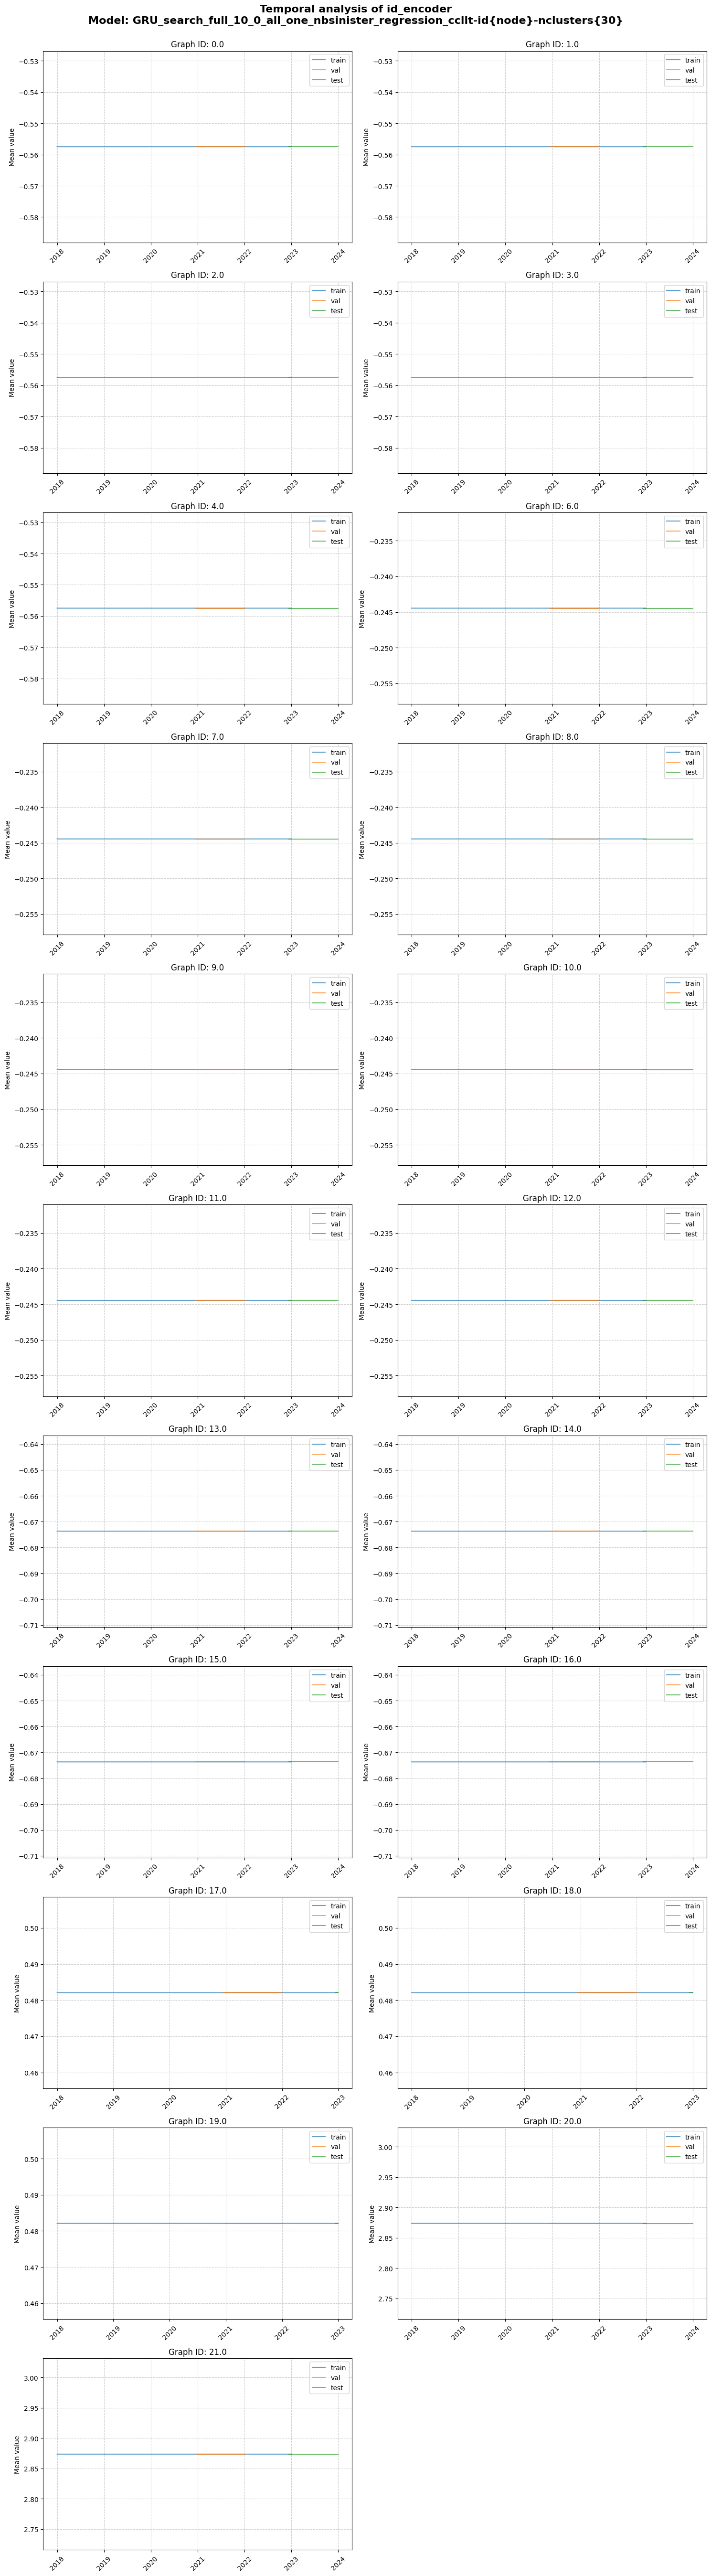

  Saved time-series plot → /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN/firemen/firepoint/2x2/train/occurence_06_01_25_78/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_nbsinister_regression_ccllt-id{node}-nclusters{30}/id_encoder_time_series.png


In [21]:
def plot_feature_time_series_by_graphids(splits: dict, features_to_plot: list, out_dir: Path, model_name: str):
    """
    Plot the mean value of specified features over time, grouped by department.
    Useful for checking if land cover features (like Corine_forest_mean) are truly static.
    """
    import matplotlib.pyplot as plt
    import pandas as pd
    try:
        from tools import allDates
    except ImportError:
        allDates = None
    
    # Combined dataframe for visualization
    all_dfs = []
    for split_name, df in splits.items():
        # Ensure we have the necessary columns
        if 'date' not in df.columns:
            continue
        
        # Identify department column
        dept_col = None
        for col in ['graph_id']:
            if col in df.columns:
                dept_col = col
                break
        
        if dept_col is None:
            continue
            
        temp_df = df[['date', dept_col] + [f for f in features_to_plot if f in df.columns]].copy()
        temp_df['split'] = split_name
        all_dfs.append(temp_df)
    
    if not all_dfs:
        print("  Warning: Required columns (date, departement) not found in splits. Skipping time-series plots.")
        return []

    df_full = pd.concat(all_dfs, ignore_index=True)
    
    # Convert date to datetime if numeric
    if allDates and pd.api.types.is_integer_dtype(df_full['date']):
        df_full['date_dt'] = df_full['date'].apply(lambda x: pd.to_datetime(allDates[x]) if 0 <= x < len(allDates) else pd.NaT)
    else:
        df_full['date_dt'] = pd.to_datetime(df_full['date'])
    
    # Drop rows with invalid dates
    df_full = df_full.dropna(subset=['date_dt'])
    
    saved_paths = []
    
    for feat in features_to_plot:
        if feat not in df_full.columns:
            continue
            
        depts = sorted(df_full[dept_col].unique())
        n_depts = len(depts)
        if n_depts == 0: continue
        
        # Create subplots for each department
        ncols = 2
        nrows = (n_depts + 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows), sharex=False)
        axes = axes.flatten() if n_depts > 1 else [axes]
        
        fig.suptitle(f"Temporal analysis of {feat}\nModel: {model_name}", fontsize=16, fontweight='bold')
        
        for i, dept in enumerate(depts):
            ax = axes[i]
            dept_df = df_full[df_full[dept_col] == dept]
            
            for split in ['train', 'val', 'test']:
                split_df = dept_df[dept_df['split'] == split]
                if split_df.empty: continue
                
                # Group by date and calculate mean
                daily_mean = split_df.groupby('date_dt')[feat].mean().sort_index()
                ax.plot(daily_mean.index, daily_mean.values, label=split, alpha=0.7)
            
            ax.set_title(f"Graph ID: {dept}")
            ax.set_ylabel("Mean value")
            ax.legend()
            ax.grid(True, linestyle='--', alpha=0.6)
            plt.setp(ax.get_xticklabels(), rotation=45)
            
        # Hide empty subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        fig.tight_layout(rect=[0, 0, 1, 0.98])
        
        safe_name = feat.replace(" ", "_").replace(",", "")
        fig_path = out_dir / f"{safe_name}_time_series.png"
        fig.savefig(fig_path, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        saved_paths.append(fig_path)
        print(f"  Saved time-series plot \u2192 {fig_path}")
        
    return saved_paths

for model_name in MODEL_NAMES:
    print(f"\nProcessing {model_name} for time-series analysis...")
    try:
        model = load_model(model_name, NODE_ROOT)
    except Exception:
        print(f"  Failed to load {model_name}")
        continue
    splits = get_split_dfs(model)
    out_dir = Path(NODE_ROOT) / model_name
    
    plot_feature_time_series_by_graphids(splits, static_features, out_dir, model_name)
